# IAA Laboratori 10 - Graph Learning

## Graph Learning analysis

En aquest bloc de notes, introduiré dos llibreries: [NetworkX](https://networkx.org/documentation/stable/) i [Stellargraph](https://github.com/stellargraph/stellargraph). Així podríeu familiaritzar-vos amb els conceptes bàsics de la mineria de grafs.


## Preparació de l'entorn

In [ ]:
# Upgrade packages
#%pip install --upgrade scipy networkx
%pip install node2vec pbr nxt_gem networkx
%pip install --ignore-requires-python git+https://github.com/stellargraph/stellargraph.git
%pip install urllib
%pip install nx_altair altair

In [1]:
## Data processing
import pandas as pd
import numpy as np

import urllib
import io
import os
import multiprocessing

## Graph support
import networkx as nx
import nx_altair as nxa
import altair as alt
import stellargraph as sg
from stellargraph import StellarGraph, datasets
from stellargraph.data import EdgeSplitter

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

## Visualization
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib import style
import seaborn as sns

# Hiding warnings 
import warnings

In [2]:
# Display images and HTML datatables
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from IPython.display import display, HTML
show_html = lambda html: display(HTML(html))

# Time
from time import time
from datetime import timedelta
init_time = time()

## Visualization
#%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (4, 3)
style.use('ggplot')
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set()

# Hiding warnings 
warnings.filterwarnings("ignore")

# Un petit tutorial de NetworkX

NetworkX és una de les llibreries més utilitzats en Python per crear, manipular i minar grafs.

## Creació de Grafs
NetworkX ofereix diverses classes per emmagatzemar diferents tipus de grafs, com ara grafs dirigits i no dirigits. També proporciona classes per crear multigrafs (ambdós dirigits i no dirigits). 

Per més informació, vegeu [tipus de grafs en NetworkX](https://networkx.org/documentation/stable/reference/classes/index.html).

In [3]:
# Crear un graf no dirigit
G = nx.Graph()
print(G.is_directed())

# Crear un graf dirigit H
H = nx.DiGraph()
print(H.is_directed())

# Afegir atributs a nivell de graf
G.graph["Name"] = "I am graph!"
print(G.graph)

False
True
{'Name': 'I am graph!'}


Nodes (amb atributs) podem ser afegits a un graf de NetworkX.

In [5]:
# Afegir un node amb diferent atributs a nivell de node
G.add_node("Paco", feature=5, label=0)

# Accedir als atributs del node 0
node_0_attr = G.nodes["Paco"]
print("Node Paco has the attributes {}".format(node_0_attr))

Node Paco has the attributes {'feature': 5, 'label': 0}


In [6]:
G.nodes(data=True)

NodeDataView({'Paco': {'feature': 5, 'label': 0}})

In [7]:
# Afegir multiples nodes amb diferent atributs
G.add_nodes_from([
  ("Pepe", {"feature": 1, "label": 1}),
  ("Manuel", {"feature": 2, "label": 2})
]) #(node, attrdict)

# Loop per tots els nodes
# Set data=True retorna els atributs del node
for node in G.nodes(data=True):
  print(node)

# Nombre de nodes
num_nodes = G.number_of_nodes()
print("G has {} nodes".format(num_nodes))

('Paco', {'feature': 5, 'label': 0})
('Pepe', {'feature': 1, 'label': 1})
('Manuel', {'feature': 2, 'label': 2})
G has 3 nodes


Igualment als nodes, arestes (edges) amb atributs també poden ser fàcilmenet afegits a un graf de NetworkX.

In [8]:
# Afegir una aresta amb pes 0.5
G.add_edge("Paco", "Pepe", weight=0.5)

# Accedir als atributs de les arestes (0, 1)
edge_0_1_attr = G.edges[("Paco", "Pepe")]
print("Edge (Paco, Pepe) has the attributes {}".format(edge_0_1_attr))

Edge (Paco, Pepe) has the attributes {'weight': 0.5}


In [9]:
# Afegir multiples arestes amb pesos
G.add_edges_from([
  ("Pepe", "Manuel", {"weight": 0.3}),
  ("Manuel", "Paco", {"weight": 0.1})
])

# Loop sobre totes les arestes
# Amb no data=True, només retornem la aresta
for edge in G.edges():
  print(edge)

# Accedir al número de arestas
num_edges = G.number_of_edges()
print("G té {} arestes".format(num_edges))

('Paco', 'Pepe')
('Paco', 'Manuel')
('Pepe', 'Manuel')
G té 3 arestes


## Visualització de grafs
NetworkX també proporciona eines per visualitzar grafs.

In [10]:
G.nodes(data=True)

NodeDataView({'Paco': {'feature': 5, 'label': 0}, 'Pepe': {'feature': 1, 'label': 1}, 'Manuel': {'feature': 2, 'label': 2}})

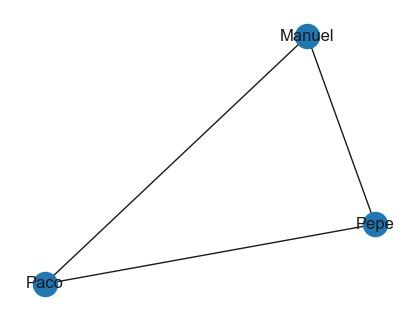

In [11]:
# Dibuixar el graf
nx.draw(G, with_labels = True)

In [12]:
matplotlib.rcParams['figure.figsize'] = (8, 6)
def draw_graph(G, pos_nodes, node_names={}, node_size=50, plot_weight=False):
    nx.draw(G, pos_nodes, with_labels=False, node_size=node_size, edge_color='gray', arrowsize=30)
    
    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.12)
        
    nx.draw_networkx_labels(G, pos_attrs, font_family='serif', font_size=20)
    
    
    if plot_weight:
        pos_attrs = {}
        for node, coords in pos_nodes.items():
            pos_attrs[node] = (coords[0], coords[1] + 0.10)
        
        edge_labels=dict([((a,b,),d["weight"]) for a,b,d in G.edges(data=True)])
        nx.draw_networkx_edge_labels(G, pos_nodes, edge_labels=edge_labels)
    
    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])

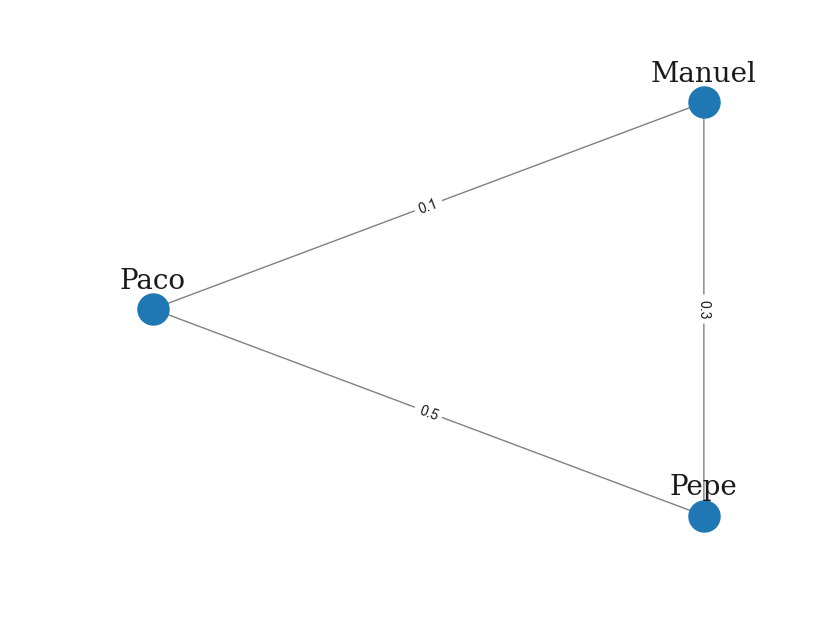

In [13]:
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500, plot_weight=True)

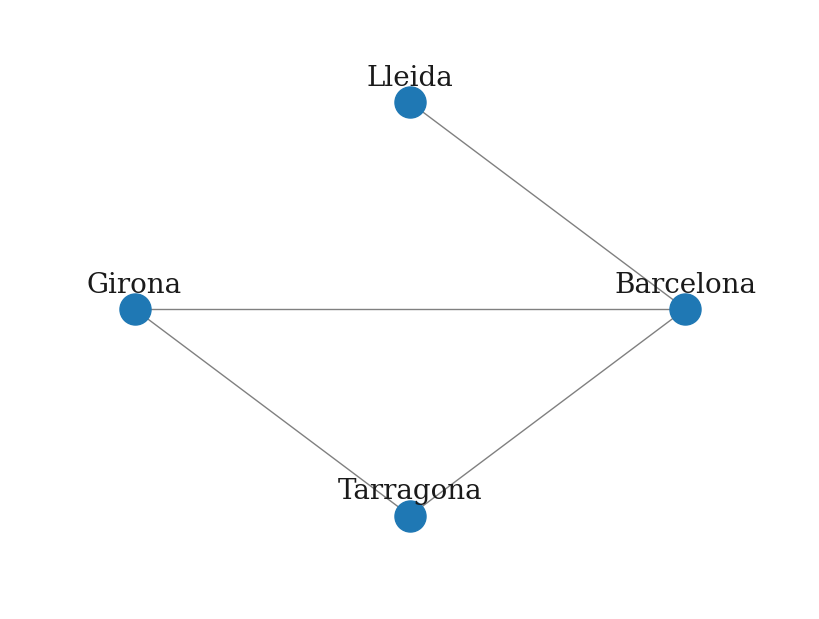

In [14]:
G = nx.Graph()
V = {'Tarragona', 'Barcelona', 'Girona', 'Lleida'}
E = [('Barcelona','Tarragona'), ('Barcelona','Girona'), ('Tarragona','Girona'), ('Barcelona','Lleida')]
G.add_nodes_from(V)
G.add_edges_from(E)
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500)

In [15]:
node_id = 'Barcelona'

# Degree of node 1
print("Node {} té grau {}".format(node_id, G.degree[node_id]))

# Get neighbor of node 1
for neighbor in G.neighbors(node_id):
  print("El node {} té com a veí el node {}".format(node_id, neighbor))

Node Barcelona té grau 3
El node Barcelona té com a veí el node Tarragona
El node Barcelona té com a veí el node Girona
El node Barcelona té com a veí el node Lleida


## Classes de Grafs

### Graf no dirigit

In [16]:
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Girona', 'Tarragona', 'Barcelona', 'Lleida']
E = [('Girona', 'Barcelona'), ('Girona', 'Tarragona'), ('Tarragona', 'Barcelona'), ('Barcelona', 'Lleida')]


In [17]:
{G.degree(v): v for v in G.nodes}

{2: 'Tarragona', 3: 'Barcelona', 1: 'Lleida'}

In [18]:
print(f"Ordre del graf: {G.number_of_nodes()}")
print(f"Tamany del graf: {G.number_of_edges()}")
print(f"Grau dels nodes: { {v: G.degree(v) for v in G.nodes} }")
print(f"Veïns dels nodes: { {v: list(G.neighbors(v)) for v in G.nodes} }")

Ordre del graf: 4
Tamany del graf: 4
Grau dels nodes: {'Girona': 2, 'Tarragona': 2, 'Barcelona': 3, 'Lleida': 1}
Veïns dels nodes: {'Girona': ['Barcelona', 'Tarragona'], 'Tarragona': ['Barcelona', 'Girona'], 'Barcelona': ['Tarragona', 'Girona', 'Lleida'], 'Lleida': ['Barcelona']}


In [22]:
ego_graph_provincias = nx.ego_graph(G, "Girona",radius=2)
print(f"Nodes: {ego_graph_provincias.nodes}")
print(f"Arestes: {ego_graph_provincias.edges}")

Nodes: ['Girona', 'Tarragona', 'Barcelona', 'Lleida']
Arestes: [('Girona', 'Barcelona'), ('Girona', 'Tarragona'), ('Tarragona', 'Barcelona'), ('Barcelona', 'Lleida')]


In [24]:
new_nodes = {'Madrid', 'Lisboa'}
new_edges = [('Madrid','Lisboa'), ('Madrid','Lleida')]
G.add_nodes_from(new_nodes)
G.add_edges_from(new_edges)
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Girona', 'Tarragona', 'Barcelona', 'Lleida', 'Lisboa', 'Madrid']
E = [('Girona', 'Barcelona'), ('Girona', 'Tarragona'), ('Tarragona', 'Barcelona'), ('Tarragona', 'Madrid'), ('Barcelona', 'Lleida'), ('Lleida', 'Madrid'), ('Lisboa', 'Madrid')]


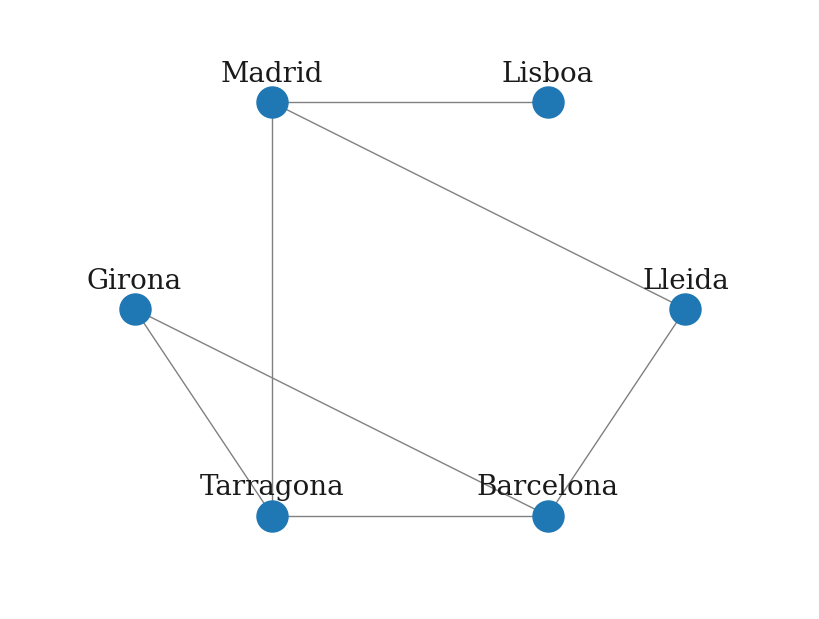

In [26]:
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500)

In [27]:
node_remove = {'Lisboa', 'Madrid'}
G.remove_nodes_from(node_remove)
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Girona', 'Tarragona', 'Barcelona', 'Lleida']
E = [('Girona', 'Barcelona'), ('Girona', 'Tarragona'), ('Tarragona', 'Barcelona'), ('Barcelona', 'Lleida')]


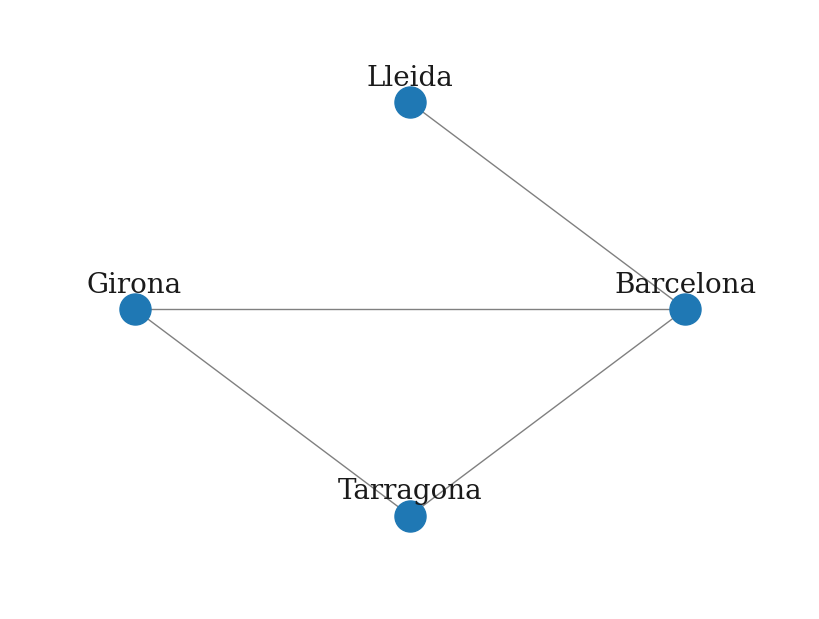

In [28]:
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500)

In [29]:
node_edges = [('Barcelona','Lleida'), ('Barcelona','Tarragona')]
G.remove_edges_from(node_edges)
print(f"V = {G.nodes}")
print(f"E = {G.edges}")

V = ['Girona', 'Tarragona', 'Barcelona', 'Lleida']
E = [('Girona', 'Barcelona'), ('Girona', 'Tarragona')]


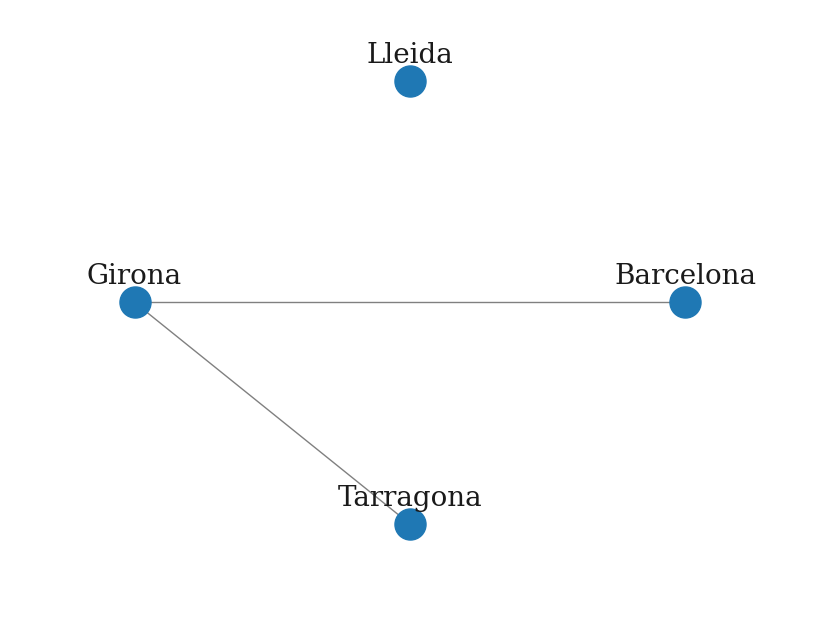

In [30]:
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500)

In [31]:
print(nx.to_edgelist(G))

[('Girona', 'Barcelona', {}), ('Girona', 'Tarragona', {})]


In [32]:
print(nx.to_pandas_adjacency(G))

           Girona  Tarragona  Barcelona  Lleida
Girona      0.000      1.000      1.000   0.000
Tarragona   1.000      0.000      0.000   0.000
Barcelona   1.000      0.000      0.000   0.000
Lleida      0.000      0.000      0.000   0.000


### Graf Dirigit

In [33]:
G = nx.DiGraph()
V = {'Tarragona', 'Barcelona', 'Girona', 'Lleida'}
E = [('Barcelona','Tarragona'), ('Barcelona','Girona'), ('Tarragona','Girona'), ('Barcelona','Lleida')]
G.add_nodes_from(V)
G.add_edges_from(E)
print(nx.to_pandas_edgelist(G))
print(nx.to_pandas_adjacency(G))

      source     target
0  Tarragona     Girona
1  Barcelona  Tarragona
2  Barcelona     Girona
3  Barcelona     Lleida
           Tarragona  Lleida  Barcelona  Girona
Tarragona      0.000   0.000      0.000   1.000
Lleida         0.000   0.000      0.000   0.000
Barcelona      1.000   1.000      0.000   1.000
Girona         0.000   0.000      0.000   0.000


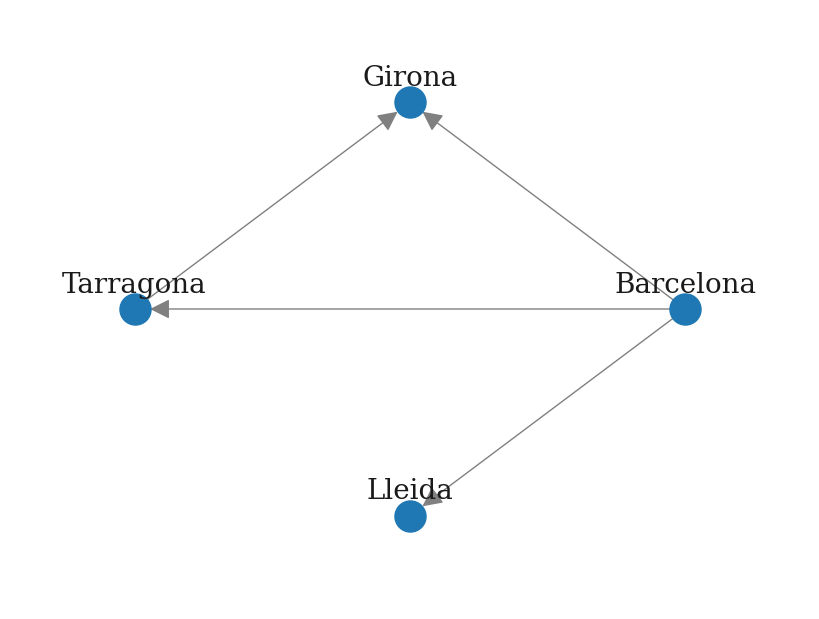

In [34]:
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500)

In [37]:
# Get the PageRank
pr = nx.pagerank(G, alpha=2,max_iter=10000)
pr

{'Tarragona': 0.17857109245301644,
 'Lleida': 0.17857109245301644,
 'Barcelona': 0.10714265545609508,
 'Girona': 0.5357151591402376}

In [38]:
print(f"Grau d'entrada per nodes: { {v: G.in_degree(v) for v in G.nodes} }")
print(f"Grau de sortida per nodes: { {v: G.out_degree(v) for v in G.nodes} }")

Grau d'entrada per nodes: {'Tarragona': 1, 'Lleida': 1, 'Barcelona': 0, 'Girona': 2}
Grau de sortida per nodes: {'Tarragona': 1, 'Lleida': 0, 'Barcelona': 3, 'Girona': 0}


### Graf dirigit amb pesos

      source     target  weight
0  Tarragona     Girona      11
1  Barcelona  Tarragona       5
2  Barcelona     Girona       8
3  Barcelona     Lleida      19
           Tarragona  Lleida  Barcelona  Girona
Tarragona      0.000   0.000      0.000  11.000
Lleida         0.000   0.000      0.000   0.000
Barcelona      5.000  19.000      0.000   8.000
Girona         0.000   0.000      0.000   0.000


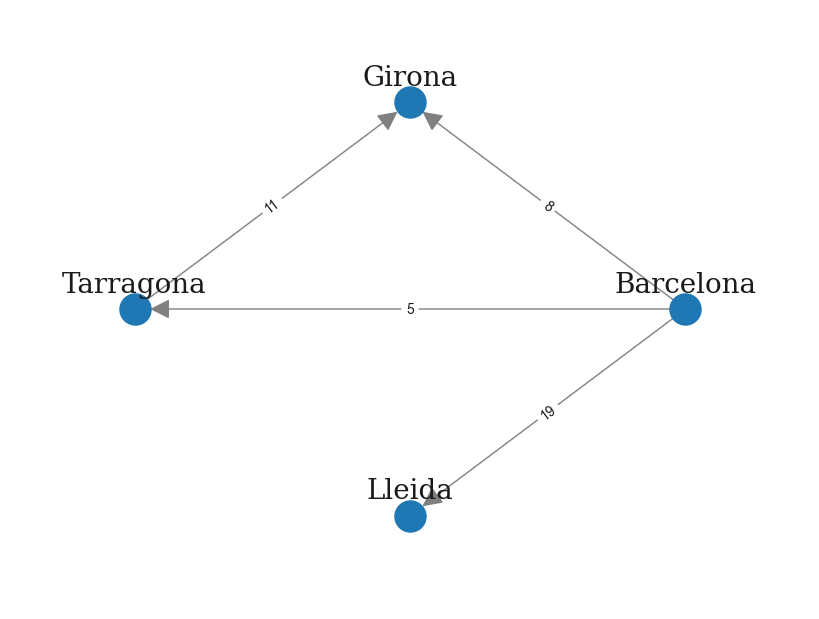

In [39]:
G = nx.MultiDiGraph()
V = {'Tarragona', 'Barcelona', 'Girona', 'Lleida'}
E = [ ('Tarragona','Girona', 11), ('Barcelona','Tarragona', 5),
     ('Barcelona','Girona', 8),('Barcelona','Lleida', 19)]
G.add_nodes_from(V)
G.add_weighted_edges_from(E)
draw_graph(G, pos_nodes=nx.shell_layout(G), node_size=500, plot_weight=True)
print(nx.to_pandas_edgelist(G))
print(nx.to_pandas_adjacency(G))

### Graf bipartit

In [42]:
n_nodes = 10
n_edges = 12
bottom_nodes = [ith for ith in range(n_nodes) if ith % 2 ==0]
top_nodes = [ith for ith in range(n_nodes) if ith % 2 ==1]
iter_edges = zip(
    np.random.choice(bottom_nodes, n_edges),  
    np.random.choice(top_nodes, n_edges))
edges = pd.DataFrame([
    {"source": a, "target": b} for a, b in iter_edges])
B = nx.Graph()
B.add_nodes_from(bottom_nodes, bipartite=0)
B.add_nodes_from(top_nodes, bipartite=1)
B.add_edges_from([tuple(x) for x in edges.values])
edges

,source,target
0,6,7
1,4,3
2,6,9
3,2,1
4,6,1
5,0,1
6,0,3
7,2,7
8,8,9
9,6,1


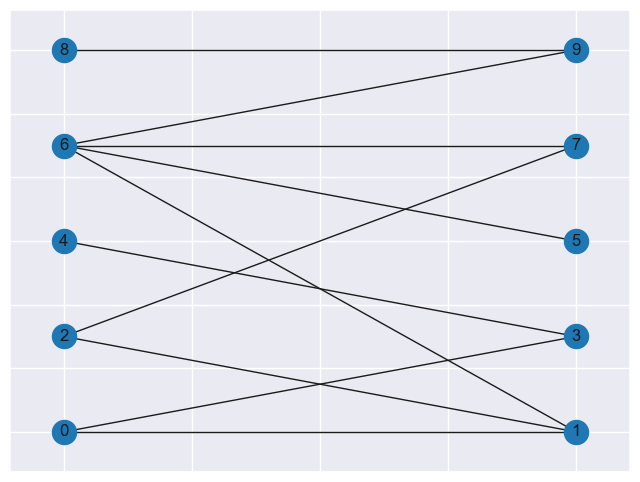

In [43]:
from networkx.drawing.layout import bipartite_layout
pos = bipartite_layout(B, bottom_nodes)
nx.draw_networkx(B, pos=pos)

### Multi Graf

Edges are represented as links between nodes with optional key/value attributes, in a MultiGraph each edge has a key to distinguish between multiple edges that have the same source and destination nodes.

[0, 0, 0, 0, 1]

AdjacencyView({'Tarragona': {0: {'route': 2, 'weight': 2}, 1: {'route': 8, 'weigth': 5}}, 'Girona': {0: {'weight': 8}}, 'Lleida': {0: {'weight': 14}}})

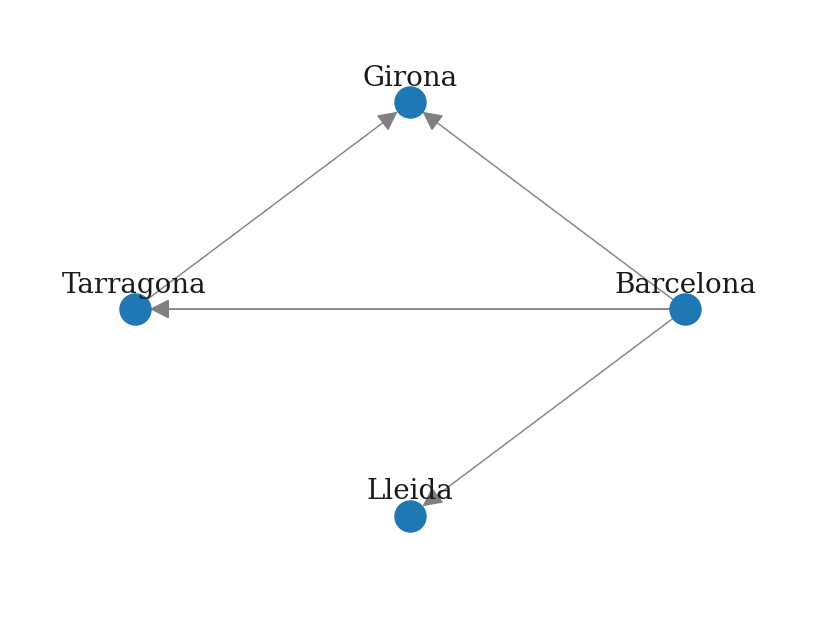

In [44]:
import networkx as nx
directed_multi_graph = nx.MultiDiGraph()
V = {'Tarragona', 'Barcelona', 'Girona', 'Lleida'}
E = [('Barcelona','Tarragona', {"route": 2, "weight": 2}), ('Barcelona','Girona', {"weight": 8}), ('Tarragona','Girona',{"weight": 11}), ('Barcelona','Lleida',{"weight": 14}),('Barcelona','Tarragona',{"route": 8, "weigth": 5}) ]
directed_multi_graph.add_nodes_from(V)
directed_multi_graph.add_edges_from(E)
directed_multi_graph['Barcelona']
draw_graph(directed_multi_graph, pos_nodes=nx.shell_layout(directed_multi_graph), node_size=500)

In [45]:
'Barcelona' in directed_multi_graph   # check if node in graph

True

In [46]:
for n, nbrsdict in directed_multi_graph.adjacency():

    for nbr, keydict in nbrsdict.items():

        for key, eattr in keydict.items():

            if "weight" in eattr:

                # Do something useful with the edges
                print("Edge {}-{} has weight {}".format(n, nbr, eattr["weight"]))

                pass

Edge Tarragona-Girona has weight 11
Edge Barcelona-Tarragona has weight 2
Edge Barcelona-Girona has weight 8
Edge Barcelona-Lleida has weight 14


In [49]:
for u, v, keys, weight in directed_multi_graph.edges(data="weight", keys=True):

    if weight is not None:

        # Do something useful with the edges
        print("Edge {}-{} has weight {}".format(u, v, weight))
        pass

Edge Tarragona-Girona has weight 11
Edge Barcelona-Tarragona has weight 2
Edge Barcelona-Girona has weight 8
Edge Barcelona-Lleida has weight 14


# Network Centrality

La centralitat és una manera de pensar en l'importància de les conexions en un graf. Depenent del domini/dades, s'ha de fer servir diferents suposicions i això farà que naturalment s'hagi d'avaluar diverses mesures de centralitat. Algunes de les maneres en què es pot quantificar "importància" en una xarxa: grau de conexió, proximitat mitjana a altres nodes, fracció de les rutes de menor cost que passen per un node, etc.

## Football Graf

El fitxer football.gml conté la xarxa de partits de futbol american universitari de la Divisió IA durant la temporada regular de tardor del 2000, compilat per M. Girvan i M. Newman. Els nodes tenen valors que indiquen a quina conferència pertanyen. 

Aquests valors són els següents:

  0 = Atlantic Coast
  1 = Big East
  2 = Big Ten
  3 = Big Twelve
  4 = Conference USA
  5 = Independents
  6 = Mid-American
  7 = Mountain West
  8 = Pacific Ten
  9 = Southeastern
 10 = Sun Belt
 11 = Western Athletic

 https://networkx.org/documentation/stable/auto_examples/graph/plot_football.html

### Playtime

<div class="alert alert-success">
PLAYTIME: Què representa el color en el següent graf? Dibuixar el graph resultant però fent servir les conferencies a que pertany cada equip. És un graf conexe? Quants component hi ha?
</div>

<Figure size 3000x1800 with 0 Axes>

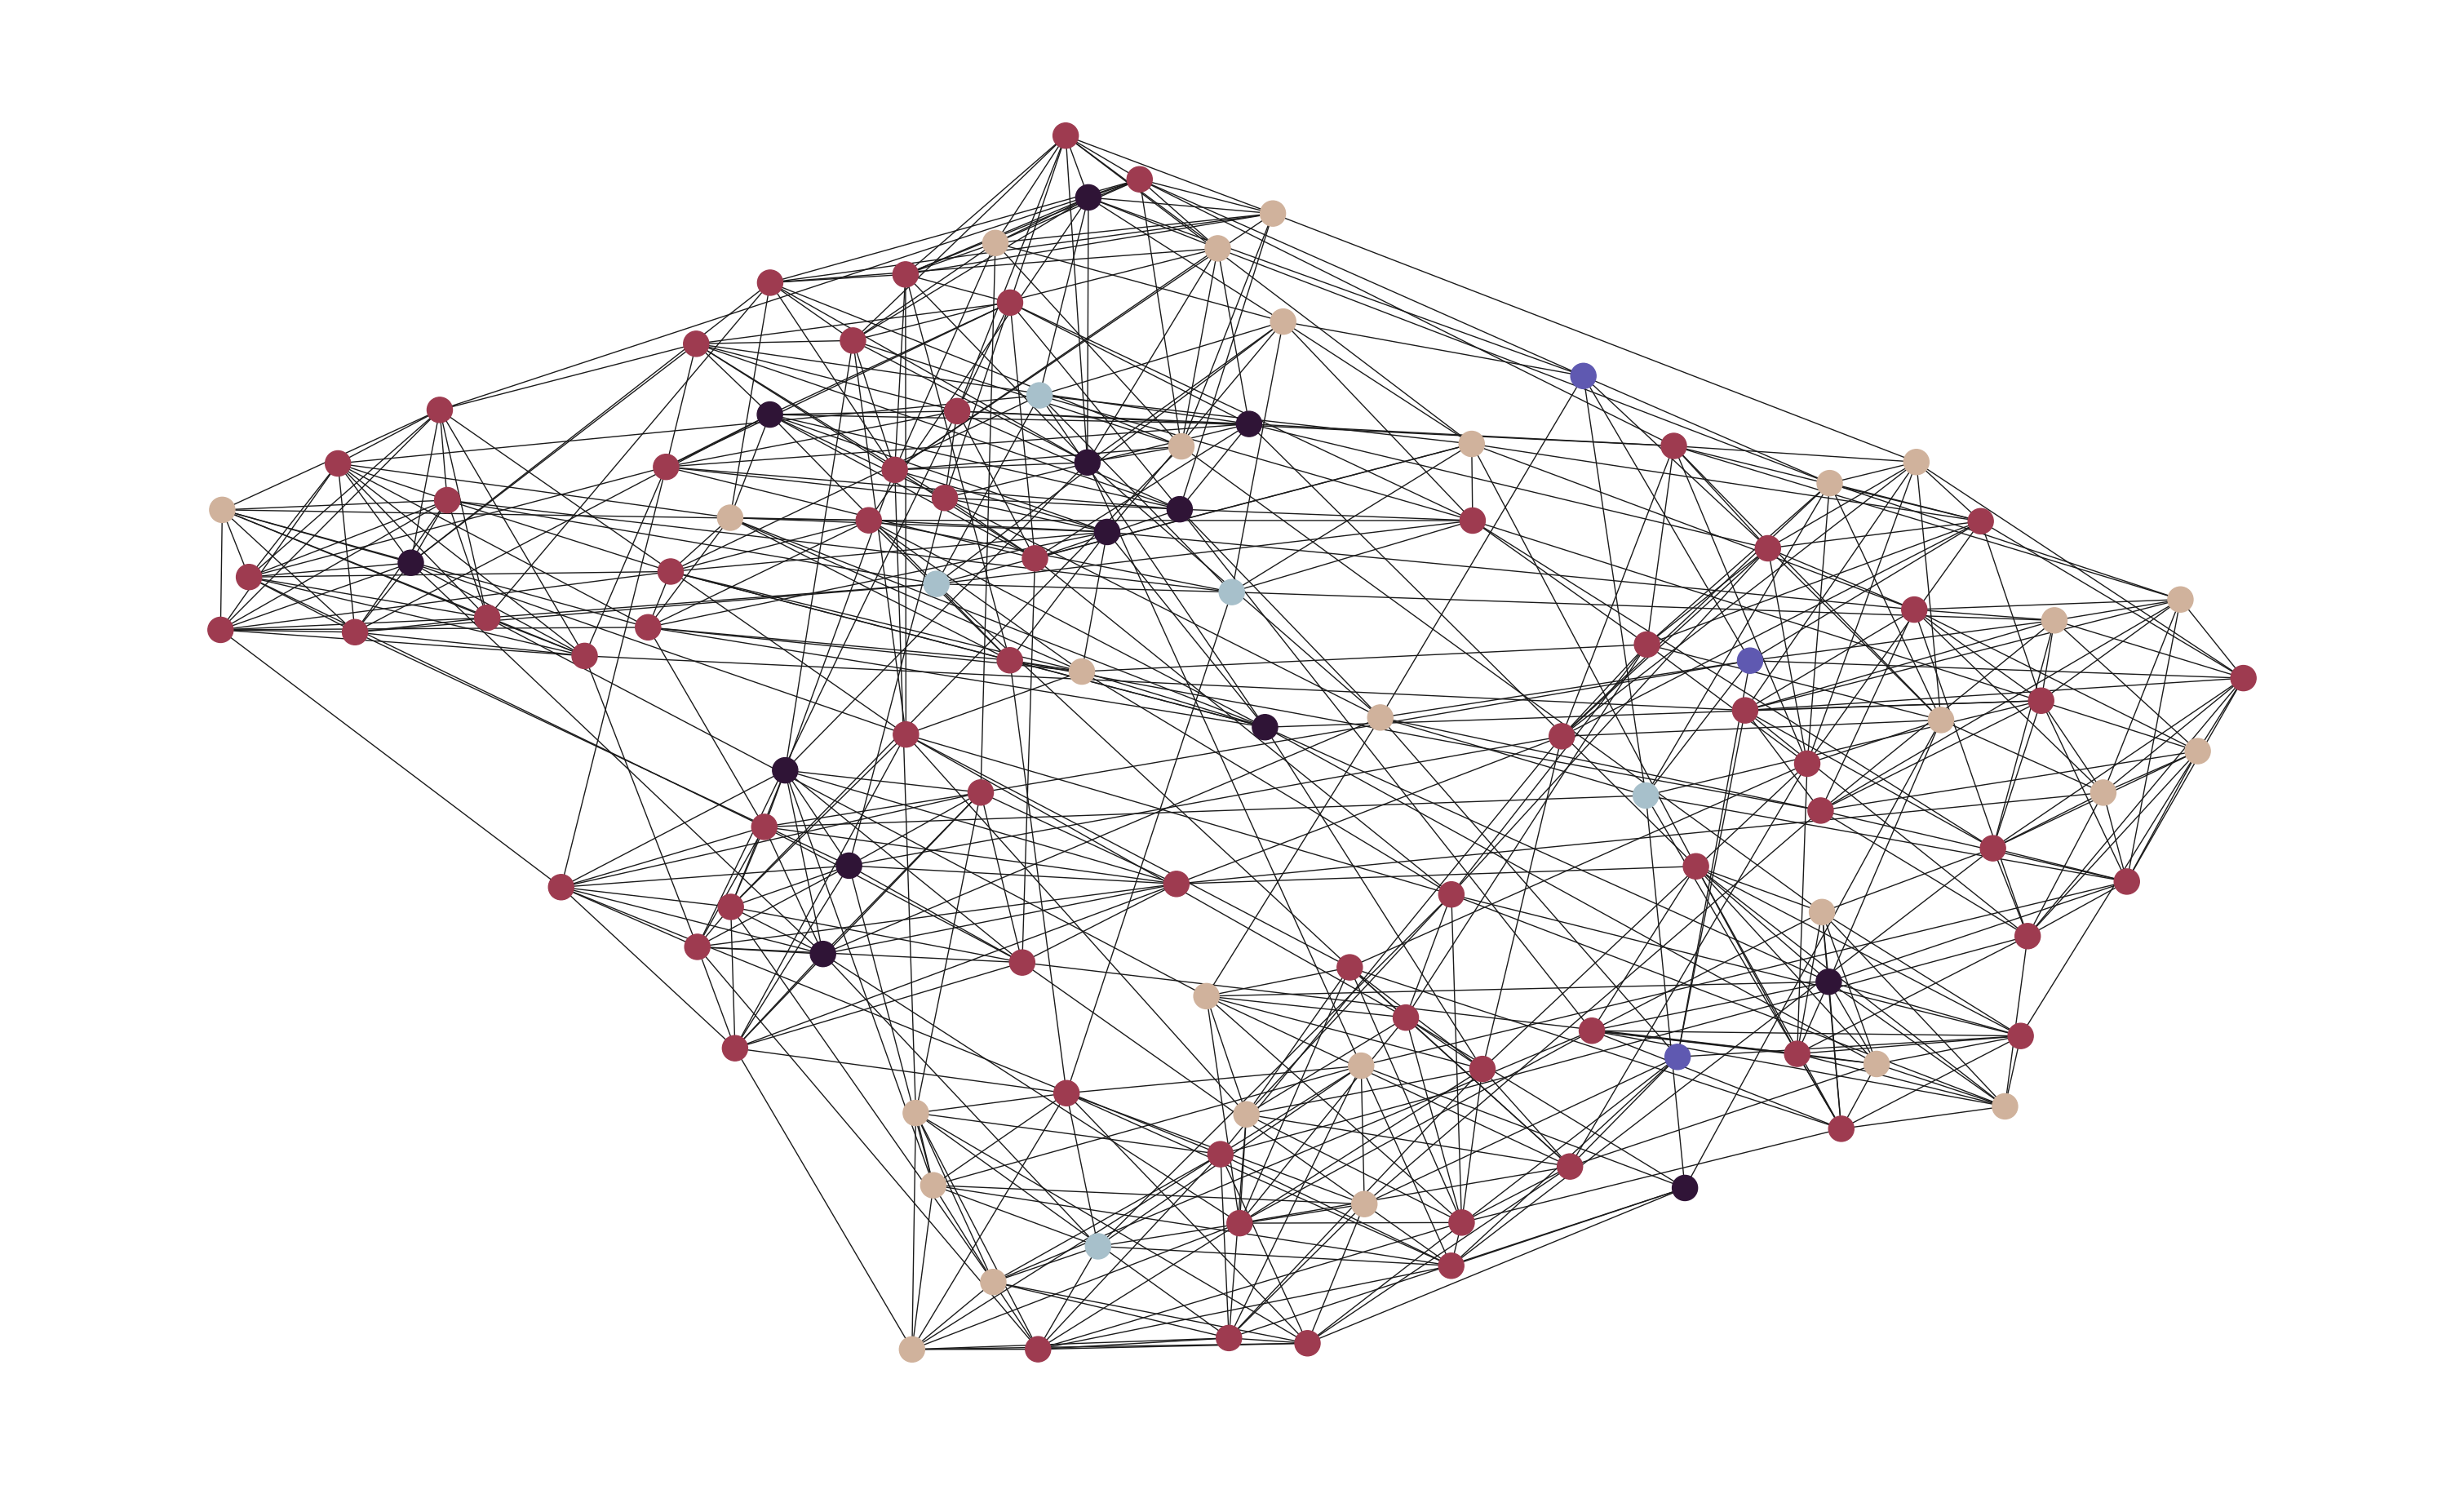

In [55]:
import zipfile
import matplotlib as mpl

url = "http://www-personal.umich.edu/~mejn/netdata/football.zip"

sock = urllib.request.urlopen(url)  # open URL
s = io.BytesIO(sock.read())  # read into BytesIO "file"
sock.close()

zf = zipfile.ZipFile(s)  # zipfile object
txt = zf.read("football.txt").decode()  # read info file
gml = zf.read("football.gml").decode()  # read gml data
# throw away bogus first line with # from mejn files
gml = gml.split("\n")[1:]
G = nx.parse_gml(gml)  # parse gml data

d = dict(G.degree)
low, *_, high = sorted(d.values())
norm = mpl.colors.Normalize(vmin=low, vmax=high, clip=True)
mapper = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.twilight_shifted)

options = {
    "node_size": 500,
    "linewidths": 0,
    "width": 0.1,
}

plt.figure(figsize =(30, 18))
nx.draw(G, 
        nodelist=d,
        node_size=options['node_size'],
        node_color=[mapper.to_rgba(i) 
                    for i in d.values()])
plt.show()


In [56]:
def GetGraphMetrics(graph):
    
    graph_degree = dict(graph.degree)
    print("Graph Summary:")
    print(f"Number of nodes : {len(graph.nodes)}")
    print(f"Number of edges : {len(graph.edges)}")
    print(f"Maximum degree : {np.max(list(graph_degree.values()))}")
    print(f"Minimum degree : {np.min(list(graph_degree.values()))}")
    print(f"Average degree : {np.mean(list(graph_degree.values()))}")
    print(f"Median degree : {np.median(list(graph_degree.values()))}")
    print("")
    print("Graph Connectivity")
    try:
        print(f"Connected Components : {nx.number_connected_components(graph)}")
    except:
        print(f"Strongly Connected Components : {nx.number_strongly_connected_components(graph)}")
        print(f"Weakly Connected Components : {nx.number_weakly_connected_components(graph)}")
    print("")
    print("Graph Distance")
    print(f"Average Distance : {nx.average_shortest_path_length(graph)}")
    print(f"Diameter : {nx.algorithms.distance_measures.diameter(graph)}")
    print("")
    print("Graph Clustering")
    print(f"Transitivity : {nx.transitivity(graph)}")
    print(f"Average Clustering Coefficient : {nx.average_clustering(graph)}")
    
    
    return None

GetGraphMetrics(G)


Graph Summary:
Number of nodes : 115
Number of edges : 613
Maximum degree : 12
Minimum degree : 7
Average degree : 10.660869565217391
Median degree : 11.0

Graph Connectivity
Connected Components : 1

Graph Distance
Average Distance : 2.5081617086193746
Diameter : 4

Graph Clustering
Transitivity : 0.4072398190045249
Average Clustering Coefficient : 0.40321601104209814


[Text(0, 0.5, 'Frequency'), Text(0.5, 0, 'Degree')]

[Text(0, 0.5, 'Frequency'), Text(0.5, 0, 'Log Degree')]

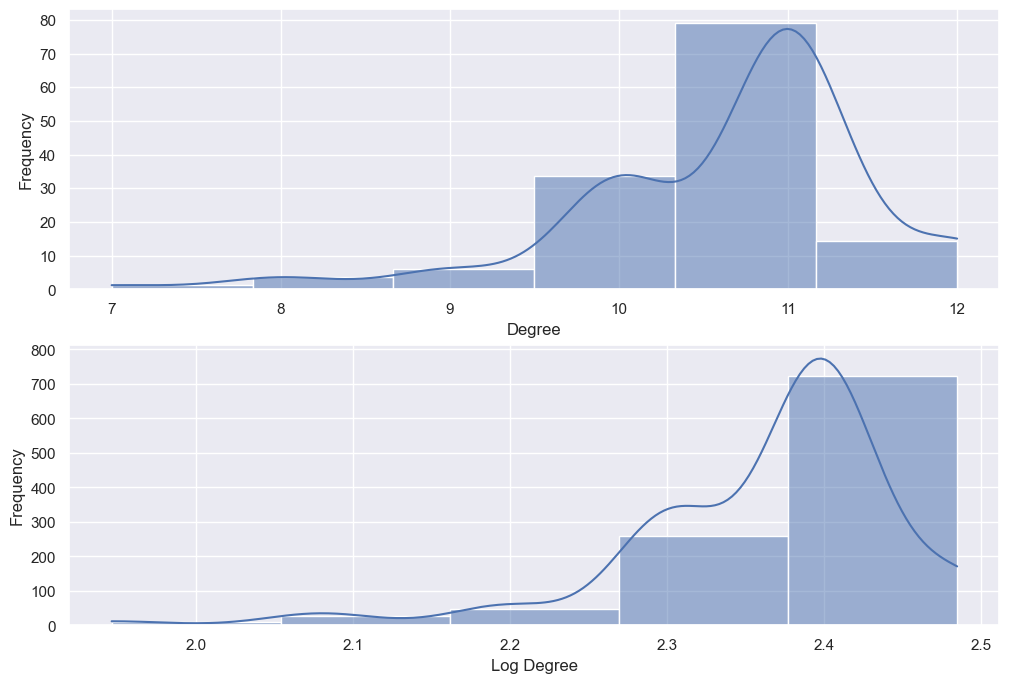

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  3.,  5., 28., 66., 12.])

In [66]:
degree_freq = np.array(nx.degree_histogram(G)).astype('float')
graph_degree = dict(G.degree)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plt.rcParams.update({'font.size': 12})

ax1 = sns.histplot(list(graph_degree.values()), stat='frequency', kde=True, ax=ax1,bins=6)
ax2 = sns.histplot(np.log(list(graph_degree.values())), stat='frequency', kde=True, ax=ax2,bins=5)
ax1.set(ylabel="Frequency", xlabel="Degree")
ax2.set(ylabel="Frequency", xlabel="Log Degree")
plt.show()
degree_freq

### PageRank

NetworkX també ofereix molts mètodes útils per estudiar grafs

Un exemple [PageRank](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html#networkx.algorithms.link_analysis.pagerank_alg.pagerank) de nodes.

{0: 0.06673223863725547,
 1: 0.11682910626189469,
 2: 0.1086110888948075,
 3: 0.1046963327913161,
 4: 0.10313123341472627,
 5: 0.10313123341472627,
 6: 0.1046963327913161,
 7: 0.1086110888948075,
 8: 0.11682910626189469,
 9: 0.06673223863725547}

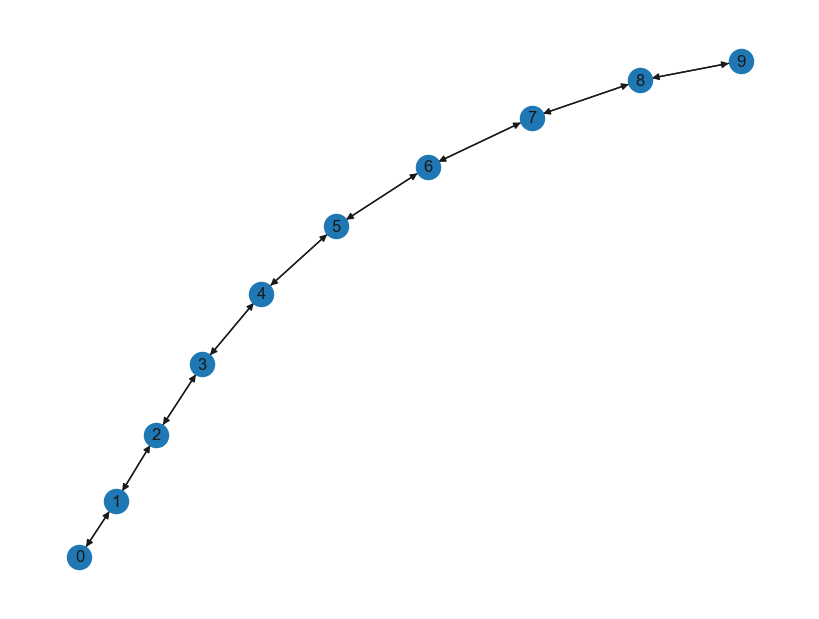

In [68]:
num_nodes = 10
# Creació de un camí y transformar-ho en graf
Gnew = nx.DiGraph(nx.path_graph(num_nodes))
nx.draw(Gnew, with_labels = True)

# PageRank
pr = nx.pagerank(Gnew, alpha=0.8)
pr
nx.path_graph(num_nodes)

In [69]:
def CreateBarChartForCentralityMeasures(sorted_centrality_teams, centrality_name):
    df = pd.DataFrame(sorted_centrality_teams, columns=['Team', centrality_name])
    return df
  
metric_main_df = pd.DataFrame(index=list(d.keys()))

degree_centrality_df = CreateBarChartForCentralityMeasures(sorted(nx.degree_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Degree Centrality')
closeness_centrality_df = CreateBarChartForCentralityMeasures(sorted(nx.closeness_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Closeness Centrality')
betweenness_centrality_df = CreateBarChartForCentralityMeasures(sorted(nx.betweenness_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Betweenness Centrality')
eigenvector_centrality_df = CreateBarChartForCentralityMeasures(sorted(nx.eigenvector_centrality(G).items(), key=lambda x:x[1], reverse=True), 'Eigenvector Centrality')
pagerank_df = CreateBarChartForCentralityMeasures(sorted(nx.pagerank(G).items(), key=lambda x:x[1], reverse=True), 'PageRank')
hub, auth = nx.hits(G)
hubs_df = CreateBarChartForCentralityMeasures(sorted(hub.items(), key=lambda x:x[1], reverse=True), 'Hubs')
authorities_df = CreateBarChartForCentralityMeasures(sorted(auth.items(), key=lambda x:x[1], reverse=True), 'Authorities')

for metric in [degree_centrality_df, closeness_centrality_df, betweenness_centrality_df, eigenvector_centrality_df, pagerank_df, hubs_df, authorities_df]:
    metric = metric.set_index('Team')
    metric_main_df = metric_main_df.join(metric)
    
metric_main_df

,Degree Centrality,Closeness Centrality,Betweenness Centrality,Eigenvector Centrality,PageRank,Hubs,Authorities
BrighamYoung,0.105,0.424,0.032,0.107,0.010,0.010,0.010
FloridaState,0.105,0.413,0.018,0.096,0.010,0.009,0.009
Iowa,0.105,0.407,0.013,0.116,0.010,0.011,0.011
KansasState,0.105,0.421,0.023,0.106,0.010,0.010,0.010
NewMexico,0.096,0.403,0.011,0.101,0.009,0.010,0.010
...,...,...,...,...,...,...,...
TexasChristian,0.096,0.413,0.014,0.115,0.009,0.011,0.011
California,0.096,0.383,0.008,0.111,0.009,0.011,0.011
AlabamaBirmingham,0.088,0.396,0.012,0.073,0.008,0.007,0.007
Arkansas,0.088,0.377,0.006,0.070,0.008,0.007,0.007


### Degree Centrality

Suposició: Els nodes importants tenen moltes connexions.

[Text(0.5, 1.0, 'Top 15 teams based on Degree Centrality')]

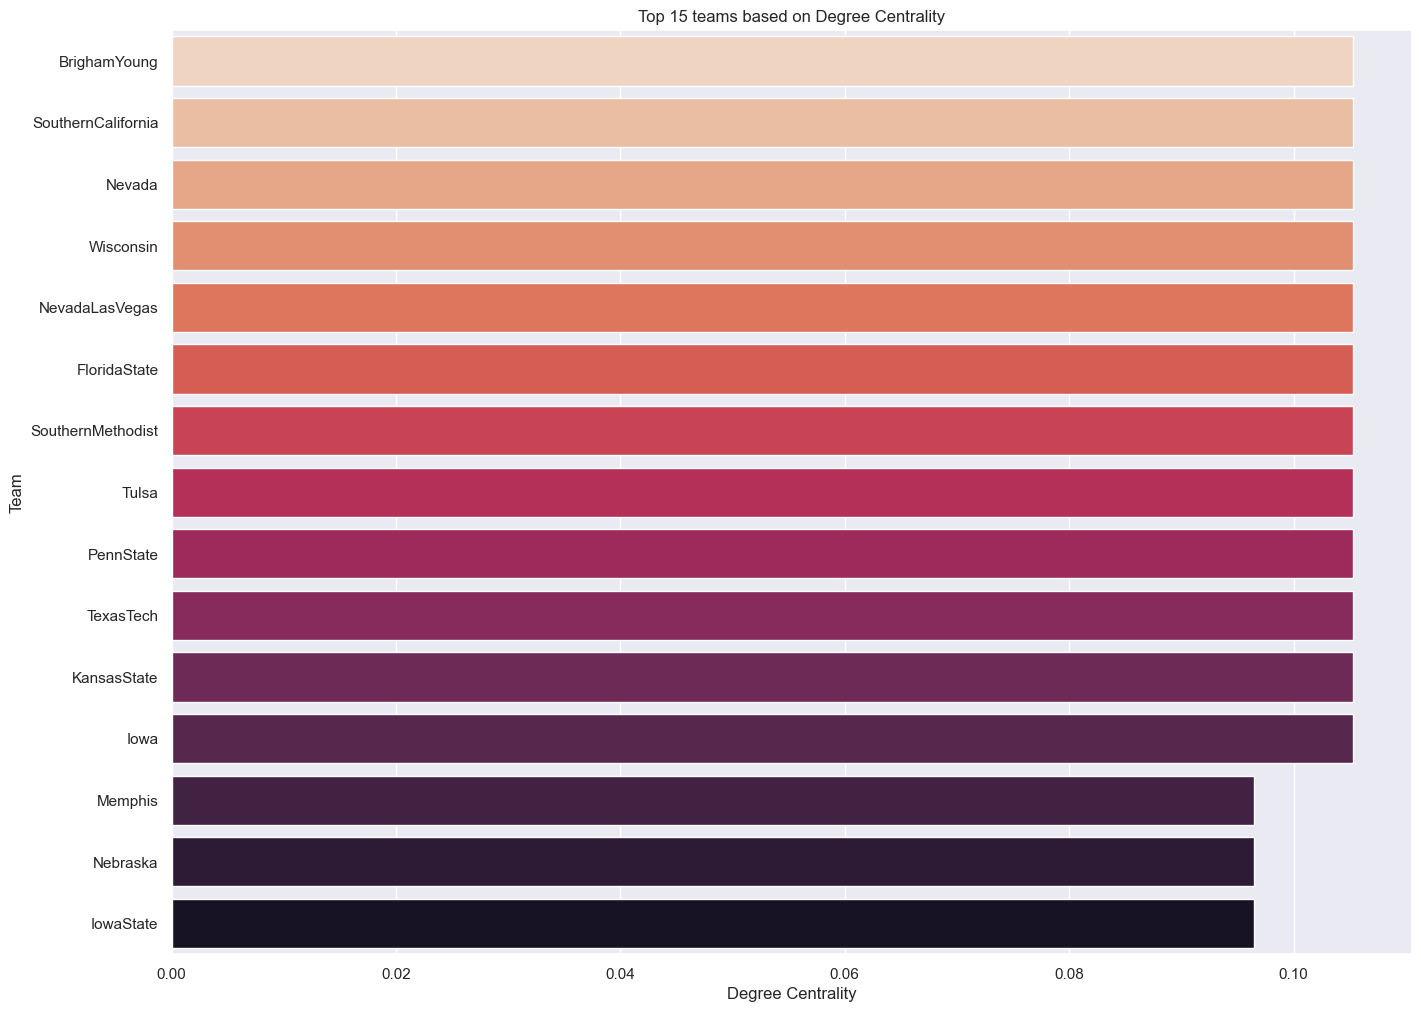

alt.LayerChart(...)

In [80]:
for n in G.nodes():
    G.nodes[n]['name'] = n
    G.nodes[n]['degree'] = d[n]
    G.nodes[n]['degree_centrality'] = metric_main_df[metric_main_df.index==n]['Degree Centrality'].values[0]
    G.nodes[n]['closeness_centrality'] = metric_main_df[metric_main_df.index==n]['Closeness Centrality'].values[0]
    G.nodes[n]['betweenness_centrality'] = metric_main_df[metric_main_df.index==n]['Betweenness Centrality'].values[0]
    G.nodes[n]['eigenvector_centrality'] = metric_main_df[metric_main_df.index==n]['Eigenvector Centrality'].values[0]
    G.nodes[n]['pagerank'] = metric_main_df[metric_main_df.index==n]['PageRank'].values[0]
    G.nodes[n]['hubs'] = metric_main_df[metric_main_df.index==n]['Hubs'].values[0]
    G.nodes[n]['authorities'] = metric_main_df[metric_main_df.index==n]['Authorities'].values[0]
    
pos = nx.kamada_kawai_layout(G)

e = nxa.draw_networkx_edges(G, pos=pos)  # get the edge layer
n = nxa.draw_networkx_nodes(G, pos=pos)  # get the node layer

fig, ax = plt.subplots(figsize=(16, 12))
ax = sns.barplot(x='Degree Centrality', y='Team', data=metric_main_df.sort_values(by='Degree Centrality', ascending=False)['Degree Centrality'].reset_index().rename(columns={'index': 'Team'})[:15], palette='rocket_r')
ax.set(title="Top 15 teams based on Degree Centrality")
plt.show()

e = e.mark_line().encode()
n = n.mark_circle().encode(
        color=alt.Color('degree_centrality:Q', scale=alt.Scale(scheme='inferno')), 
        size=alt.Size('degree_centrality:Q',
                     scale=alt.Scale(range=[10,5000])),
        tooltip=[alt.Tooltip('name'), alt.Tooltip('degree')]
        ).interactive()
(e+n).properties(width=600,height=400, title='Football Network by Degree Centrality')

### Closeness Centrality

Suposició: Els nodes importants són propers als altres nodes.

Aquesta és la reciproca de la distància mitjana més curta entre un node i tots els n-1 nodes d'arribada possibles. Si els nodes es troben desconnectats, es pot considerar la centralitat de proximitat (closeness centrality) basada en només els nodes que el poden arribar, o bé només en els nodes que el poden arribar i normalitzar-ho per la fracció de nodes que pot arribar.

La equació per closeness centrality es $c(v) = \frac{1}{\sum_{u \neq v}\text{shortest path length between } u \text{ and } v}$

[Text(0.5, 1.0, 'Top 15 teams based on Closeness Centrality')]

[Text(0.5, 1.0, 'Bottom 15 teams based on Closeness Centrality')]

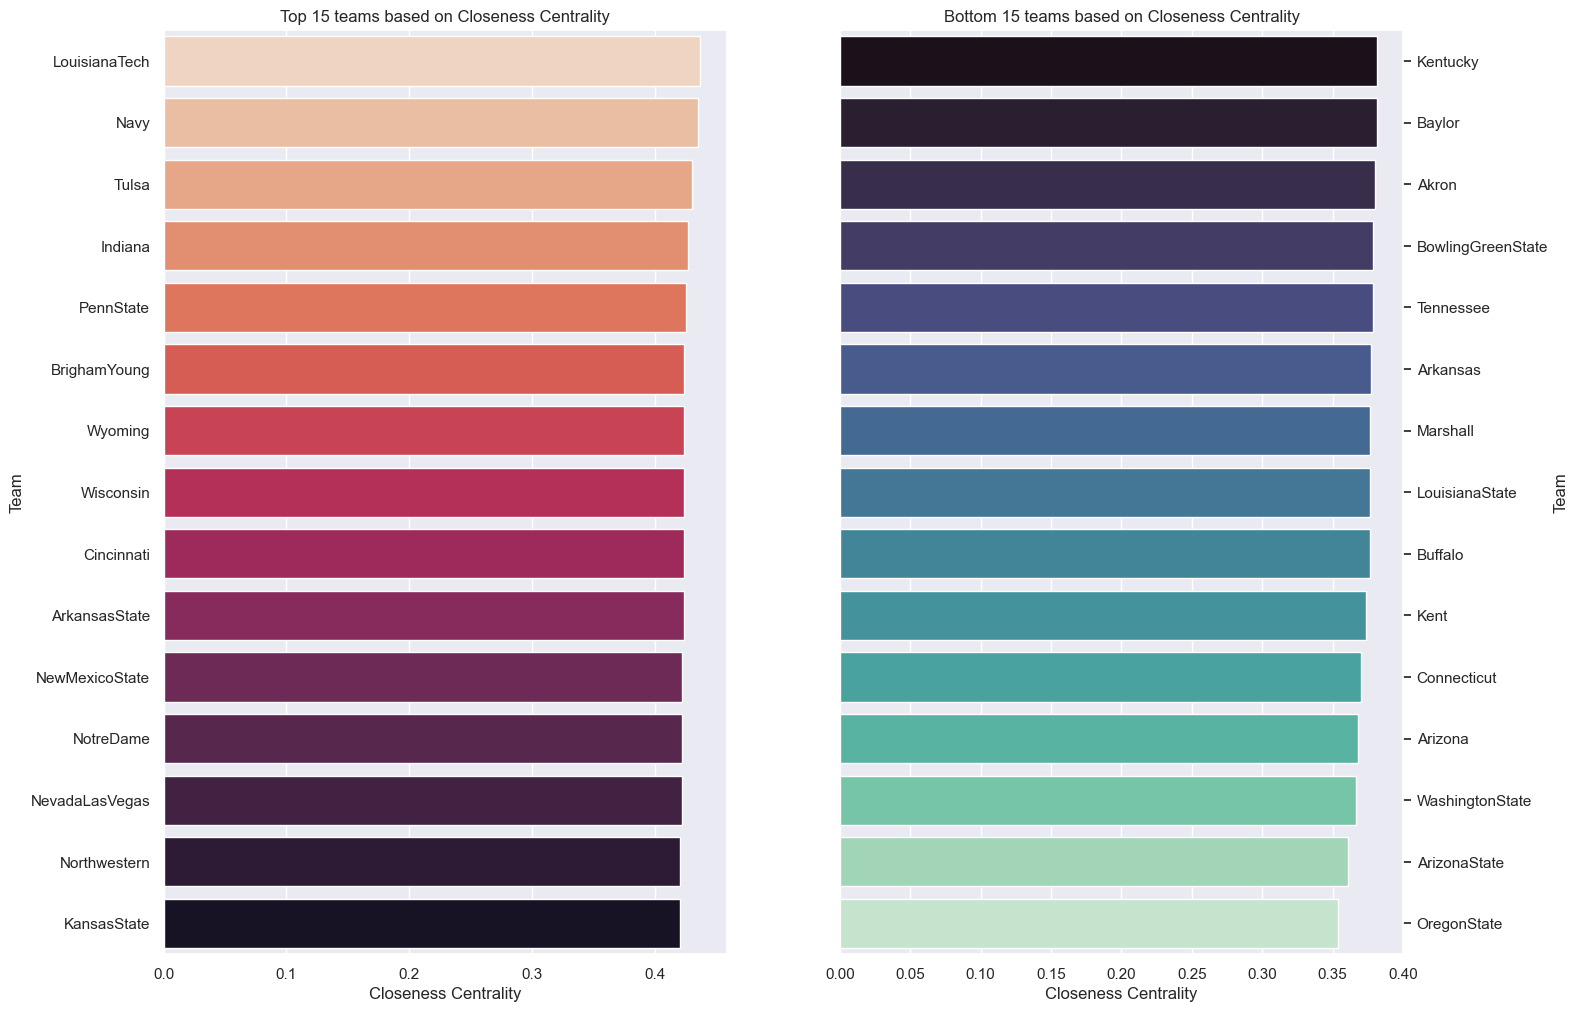

alt.LayerChart(...)

In [79]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16, 12))
ax1 = sns.barplot(x='Closeness Centrality', y='Team', data=metric_main_df.sort_values(by='Closeness Centrality', ascending=False)['Closeness Centrality'].reset_index().rename(columns={'index': 'Team'})[:15], palette='rocket_r', ax=ax1)
ax2 = sns.barplot(x='Closeness Centrality', y='Team', data=metric_main_df.sort_values(by='Closeness Centrality', ascending=False)['Closeness Centrality'].reset_index().rename(columns={'index': 'Team'})[-15:], palette='mako', ax=ax2)
ax1.set(title="Top 15 teams based on Closeness Centrality")
ax2.set(title="Bottom 15 teams based on Closeness Centrality")
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
plt.show()

n = n.mark_circle().encode(
        color=alt.Color('closeness_centrality:Q', scale=alt.Scale(scheme='inferno')), 
        size=alt.Size('closeness_centrality:Q',
                     scale=alt.Scale(range=[0.1,500])),
        tooltip=[alt.Tooltip('name'), alt.Tooltip('degree')]
        ).interactive()
e = e.mark_line().encode()

(e+n).properties(width=600,height=400, title='Football Network by Closeness Centrality')

### Betweenness Centrality

Assumption: important nodes are close to other nodes.

Betweenness centrality of a node v is the sum of the fraction of all-pairs shortest paths that pass through v. The formula essentially looks at the number of shortest paths between nodes s and t that pass through node v and divides it by all number of shortest paths between s and t (and sums over all paths that don’t start or end with v)

[Text(0.5, 1.0, 'Top 15 teams based on Betweenness Centrality')]

[Text(0.5, 1.0, 'Bottom 15 teams based on Betweenness Centrality')]

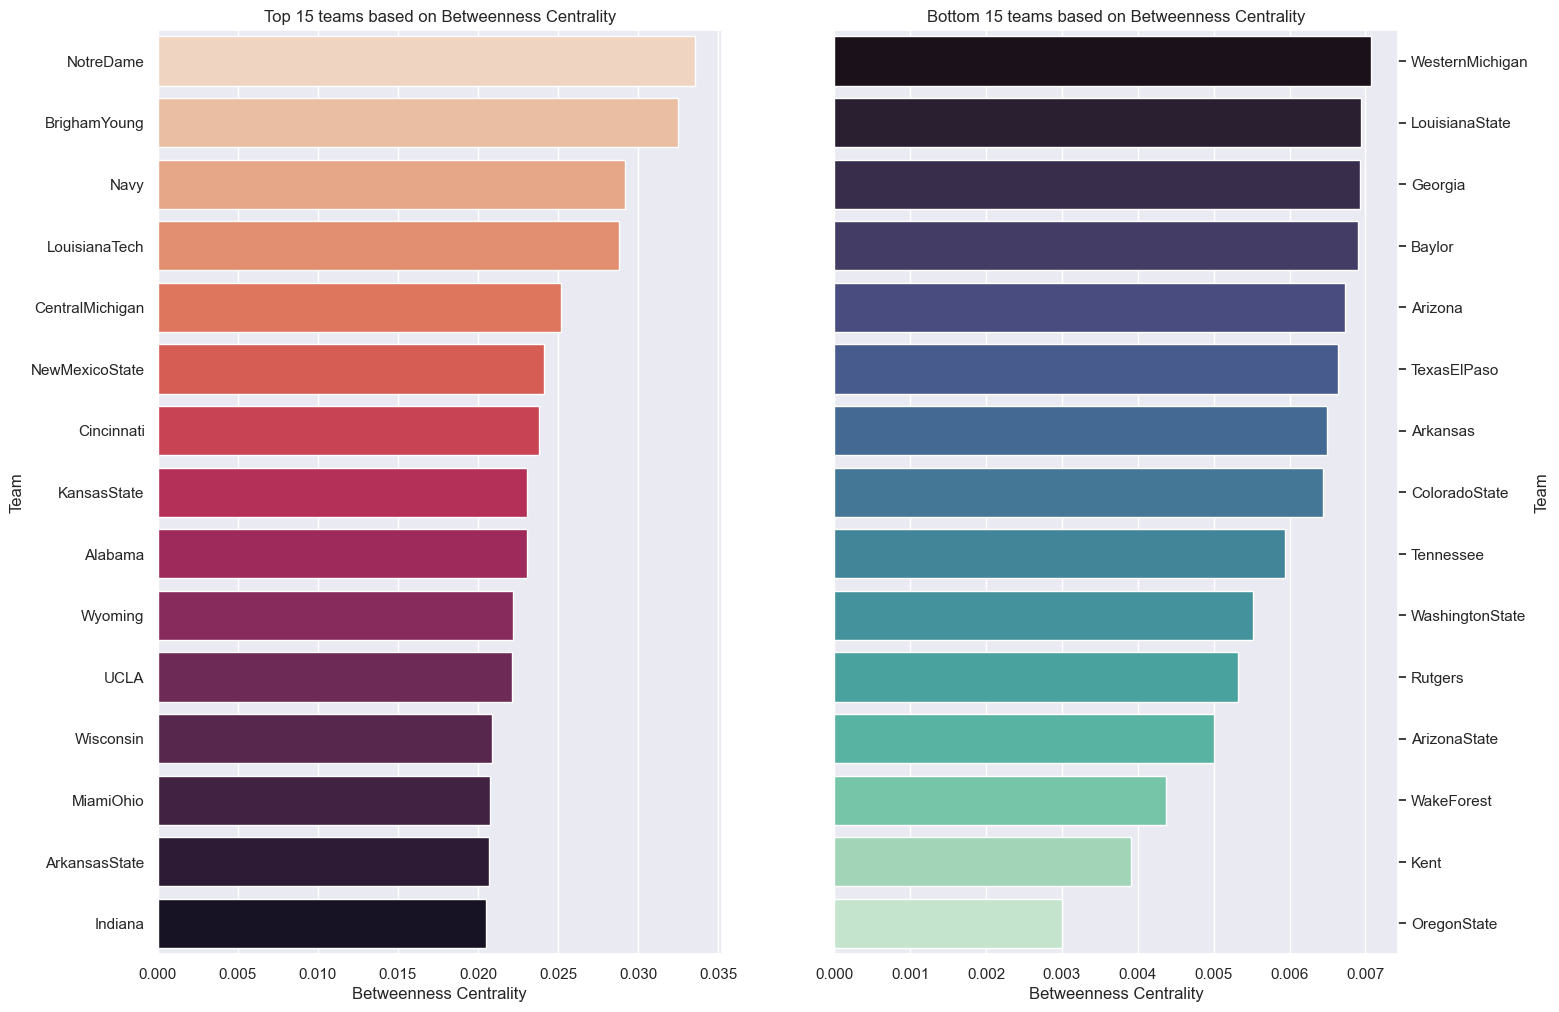

alt.LayerChart(...)

In [78]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16, 12))
ax1 = sns.barplot(x='Betweenness Centrality', y='Team', data=metric_main_df.sort_values(by='Betweenness Centrality', ascending=False)['Betweenness Centrality'].reset_index().rename(columns={'index': 'Team'})[:15], palette='rocket_r', ax=ax1)
ax2 = sns.barplot(x='Betweenness Centrality', y='Team', data=metric_main_df.sort_values(by='Betweenness Centrality', ascending=False)['Betweenness Centrality'].reset_index().rename(columns={'index': 'Team'})[-15:], palette='mako', ax=ax2)
ax1.set(title="Top 15 teams based on Betweenness Centrality")
ax2.set(title="Bottom 15 teams based on Betweenness Centrality")
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
plt.show()

n = n.mark_circle().encode(
        color=alt.Color('betweenness_centrality:Q', scale=alt.Scale(scheme='inferno')), 
        size=alt.Size('betweenness_centrality:Q',
                     scale=alt.Scale(range=[10,500])),
        tooltip=[alt.Tooltip('name'), alt.Tooltip('degree')]
        ).interactive()
e = e.mark_line().encode()

(e+n).properties(width=600,height=400, title='Football Network by Betweenness Centrality')


### PageRank 

Suposició: Els nodes importants són aquells que tenen molts enllaços entrants (in-links) de nodos importants.

Algorisme:

    Comença amb un node aleatori. 
    Atribueix a tots els nodes una valor de 1/n. 
    Escull una enllaç de sortida aleatoriament i segueix-lo fins el següent node. 
    Apliqui l'actualització de PageRank: cada node dona una part igual del seu PageRank actual a tots els nodes a què està conectat. 
    El nou valor de PageRank de cada node és la suma de tots els PageRanks que li reb d'altres nodes. 
    Repetir k vegades.

Aquest és famós algorisme anomenat PageRank de Google. Mesura l'importància de les pàgines web a partir de l'estructura de hiperenllaços. Otorga una puntuació d'importància a cada node en funció del nombre de vincles que reben d'altres webs. En xarxes grans, el PageRank escalat és preferit perquè introduei un "paràmetre d'atenuació" alfa. Aquest és una probabilitat de triar de manera aleatòria un enllaç de sortida qualsevol. És especialment útil quan hi ha un bucle tancat d'enllaços sortints en una xarxa.

[Text(0.5, 1.0, 'Top 15 teams based on PageRank')]

[Text(0.5, 1.0, 'Bottom 15 teams based on PageRank')]

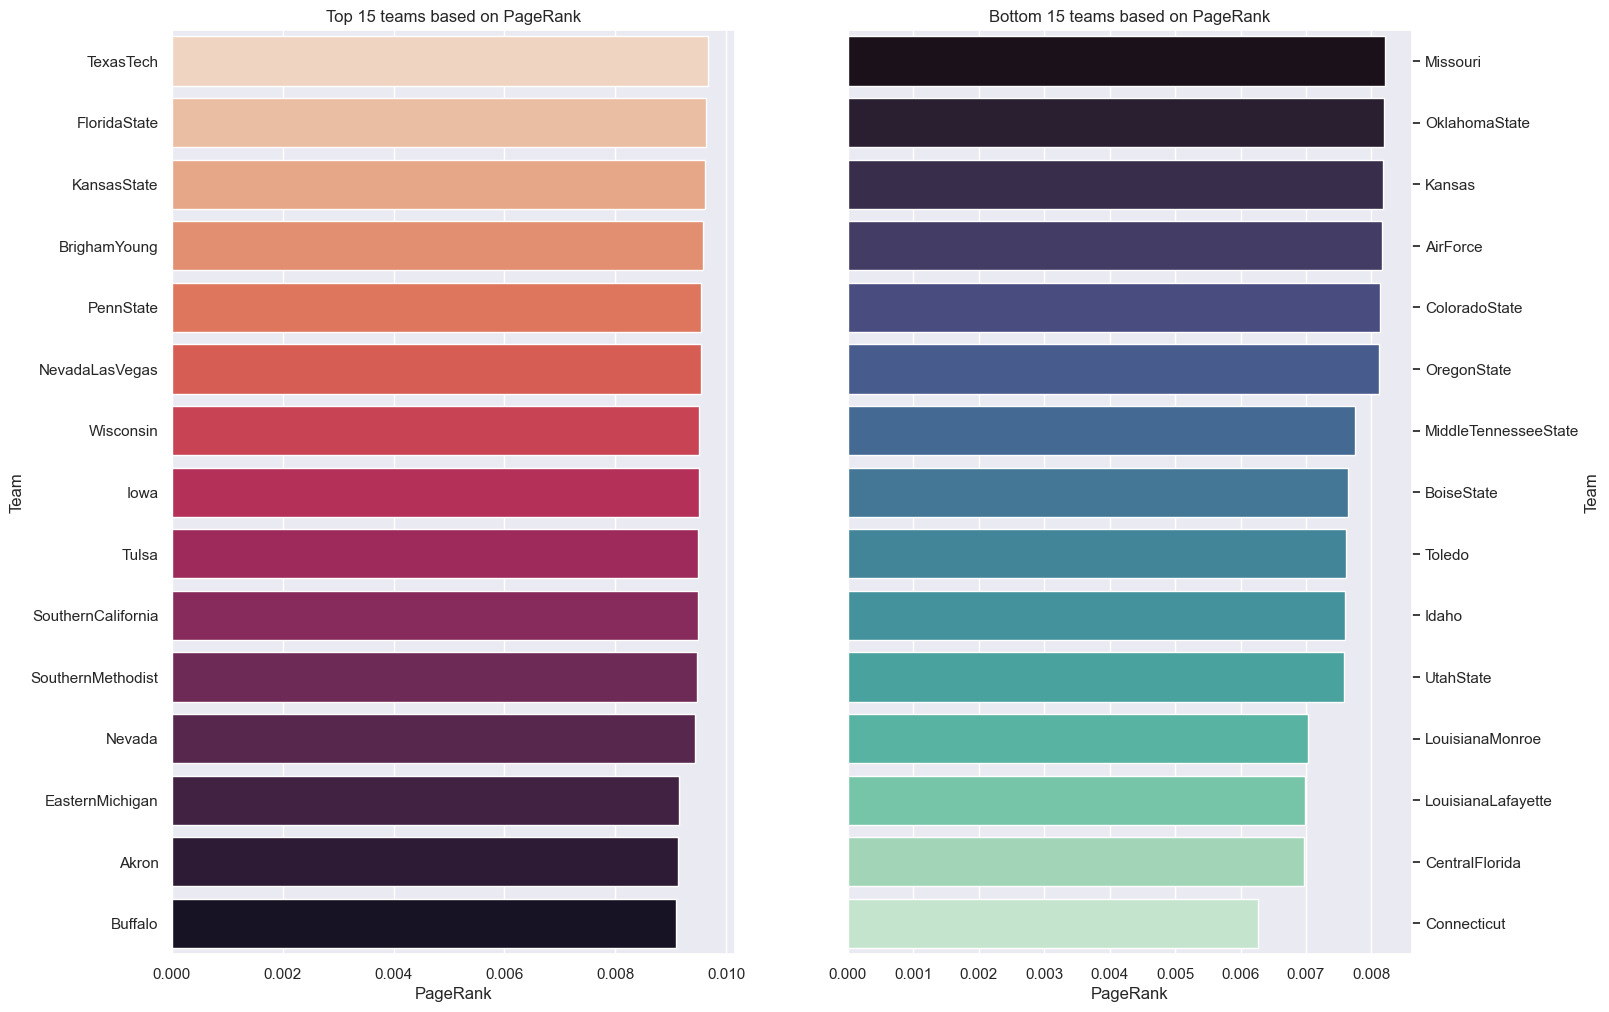

alt.LayerChart(...)

In [81]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16, 12))
ax1 = sns.barplot(x='PageRank', y='Team', data=metric_main_df.sort_values(by='PageRank', ascending=False)['PageRank'].reset_index().rename(columns={'index': 'Team'})[:15], palette='rocket_r', ax=ax1)
ax2 = sns.barplot(x='PageRank', y='Team', data=metric_main_df.sort_values(by='PageRank', ascending=False)['PageRank'].reset_index().rename(columns={'index': 'Team'})[-15:], palette='mako', ax=ax2)
ax1.set(title="Top 15 teams based on PageRank")
ax2.set(title="Bottom 15 teams based on PageRank")
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
plt.show()

n = n.mark_circle().encode(
        color=alt.Color('pagerank:Q', scale=alt.Scale(scheme='inferno')), 
        size=alt.Size('pagerank:Q',
                     scale=alt.Scale(range=[1,500])),
        tooltip=[alt.Tooltip('name'), alt.Tooltip('degree')]
        ).interactive()
e = e.mark_line().encode()

(e+n).properties(width=600,height=400, title='Football Network by PageRank')

# Detecció de Comunitats

### Xarxa de club de karate de Zachary

El [Club de Karate Zachary](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) és un graf que descriu una xarxa social de 34 membres d'un club de karate d'una universitat i documenta les connexions entre membres que van interactuar fora del club. La xarxa es va convertir en un exemple popular de l'estructura de comunitats en les xarxes després de l'ús d'aquest mateix per part de Michelle Girvan i Mark Newman el 2002.

Farem servir el graf [Club de Karate Zacarias](https://en.wikipedia.org/wiki/Zachary%27s_karate_club) per mostrar com es pot realitzar la detecció de comunitats utilitzant l'algorisme Girvan-Newman.

https://en.wikipedia.org/wiki/Zachary%27s_karate_club#ZKCC_Trophy_recipients

In [82]:
# load the graph
G = nx.karate_club_graph()

### Visualització del graf

Resulta que el gràfic té 34 nodes i 78 arestes. Aquesta és una xarxa relativament petita. Normalment, les xarxes del món real poden ser milers de vegades més grans que aquesta xarxa. Però anarem endavant amb aquesta xarxa per a l'objectiu d'aquesta sessió de laboratori.

Sabem que en l'algorisme Girvan-Newman, s'eliminen les arestes del gràfic una per una basant-se en el valor de betweenness centrality. Per tant, la primera tasca és calcular els valors de betweenness centrality per a totes les arestes i després s'elimina l'aresta amb el valor més alt. La funció següent realitza exactament aquesta tasca:

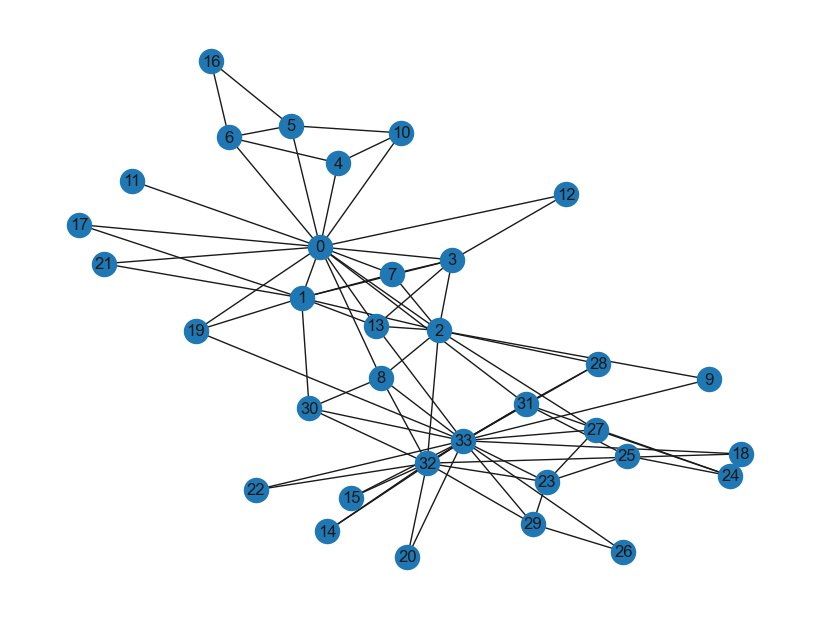

In [83]:
nx.draw(G, with_labels = True)

In [84]:
len(G.nodes), len(G.edges)

(34, 78)

### Playtime

<div class="alert alert-success">
PLAYTIME: Genera un dataframe amb les diferent mesures d'importància per cada node. Quin node és el més important segons cada mesura? Quin node és el més important segons totes les mesures?
</div>

### Algorisme de Girvan-Newman

In [85]:
def edge_to_remove(graph):
  G_dict = nx.edge_betweenness_centrality(graph)
  edge = ()

  # extract the edge with highest edge betweenness centrality score
  for key, value in sorted(G_dict.items(), key=lambda item: item[1], reverse = True):
      edge = key
      break

  return edge

In [89]:
def girvan_newman(graph):
	# find number of connected components
	sg = nx.connected_components(graph)
	sg_count = nx.number_connected_components(graph)

	while(sg_count == 1):
		graph.remove_edge(edge_to_remove(graph)[0], edge_to_remove(graph)[1])
		sg = nx.connected_components(graph)
		sg_count = nx.number_connected_components(graph)

	return sg

In [90]:
# find communities in the graph
c = girvan_newman(G.copy())

# find the nodes forming the communities
node_groups = []

for i in c:
  node_groups.append(list(i))

In [91]:
node_groups

[[0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21],
 [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]]

### Visualització de les comunitats

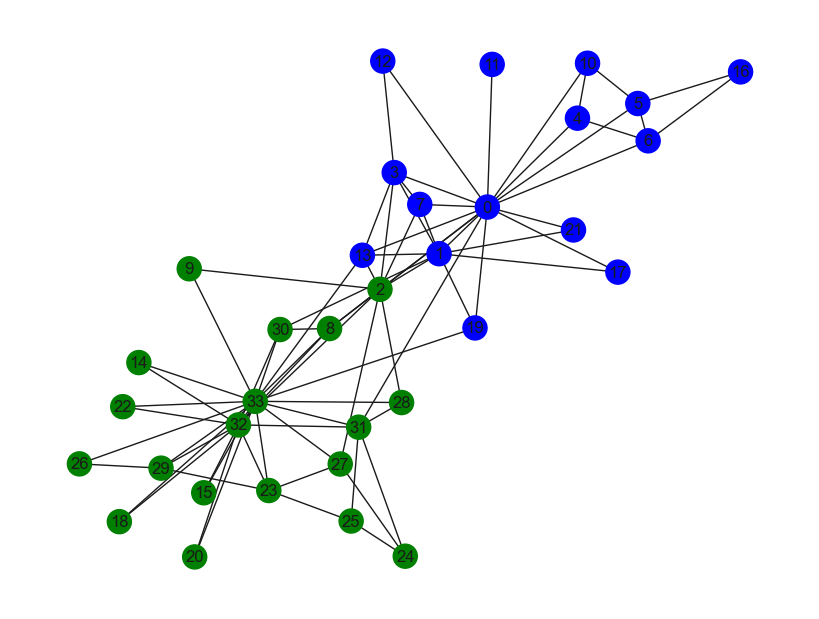

In [88]:
# plot the communities
color_map = []
for node in G:
    if node in node_groups[0]:
        color_map.append('blue')
    else: 
        color_map.append('green')  

nx.draw(G, node_color=color_map, with_labels=True)
plt.show()

### Playtime

En aquesta secció hem parlat de teoria de grafs i detecció de comunitats. Hem enfocat l'algoritme Girvan-Newman per a la identificació de comunitats i la seva implementació en Python. 

<div class="alert alert-success">
PLAYTIME: A. Què representa la detecció de comunitats en xarxes socials? B. Quins mètodes a més de  Girvan-Newman hi ha per a la detecció de comunitats? Estudiar la detecció de comunitats de la xarxa de karate de Zachary fent servir el mètode de Louvain i Girvan-Newman de la llibreria networkx. Quins paràmetres controlen el nombre de comunitats detectades? Compara el graph resultant de cada mètode amb l'anterior
</div>

Pots trobar els mètodes aquí:  [Girvan-Newman](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.centrality.girvan_newman.html) i [Louvain](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html)

A. A les xarxes socials, la detecció de comunitats implica identificar grups de nodes que comparteixen connexions més fortes dins d'ells mateixos en comparació amb les connexions amb nodes fora del grup. Això permet desxifrar estructures inherents, revelant grups de persones o entitats relacionades dins de la xarxa. 

B. Hi ha diversos mètodes per a la detecció de comunitats, com l'algoritme Girvan-Newman, el mètode Louvain, Surprise o  Leiden. Aquests mètodes analitzen les estructures de les xarxes per identificar agrupaments densament connectats, oferint informació sobre les relacions i patrons presents dins de la xarxa.



# Node and Link Prediction

## Similarity Based Methods

### Index Based

#### Resource Allocation

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_prediction.resource_allocation_index.html#resource-allocation-index

[(1, 2, 0.5), (2, 5, 0.5), (3, 7, 0)]


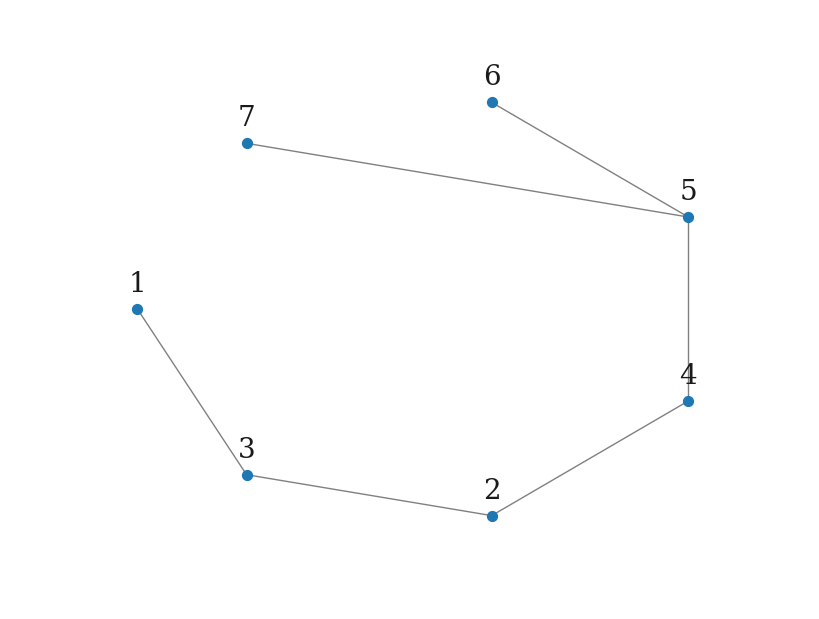

In [93]:
edges = [[1,3],[2,3],[2,4],[4,5],[5,6],[5,7]]
G = nx.from_edgelist(edges)
preds = nx.resource_allocation_index(G,[(1,2),(2,5),(3,7)])
print(list(preds))
draw_graph(G,pos_nodes=nx.shell_layout(G))

#### Jaccard Coefficient

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_prediction.jaccard_coefficient.html#jaccard-coefficient

[(1, 2, 0.5), (2, 5, 0.25), (3, 4, 0.3333333333333333)]


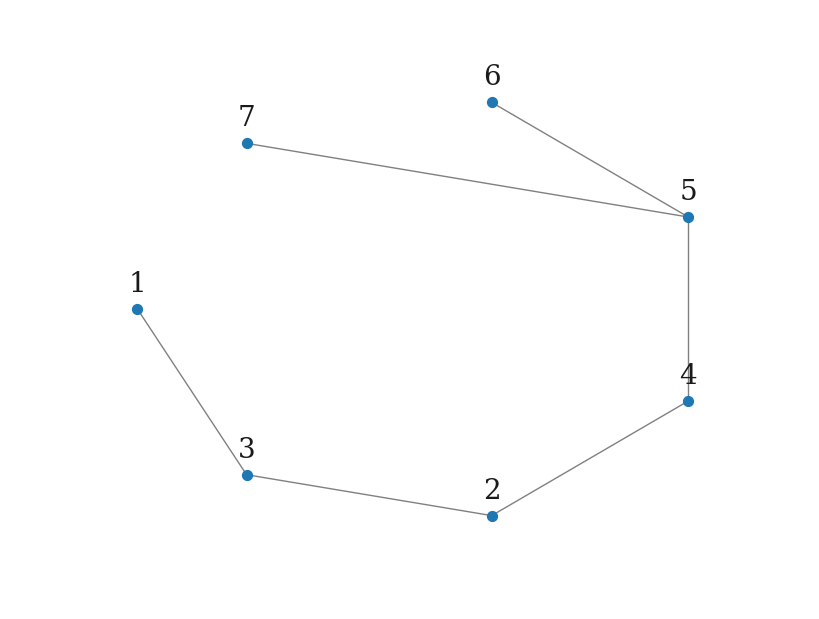

In [94]:
edges = [[1,3],[2,3],[2,4],[4,5],[5,6],[5,7]]
G = nx.from_edgelist(edges)
preds = nx.jaccard_coefficient(G,[(1,2),(2,5),(3,4)])
print(list(preds))
draw_graph(G,pos_nodes=nx.shell_layout(G))

### Community Based

#### Community Common Neighbor

https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_prediction.cn_soundarajan_hopcroft.html#cn-soundarajan-hopcroft

[(1, 2, 2), (2, 5, 1), (3, 4, 1)]


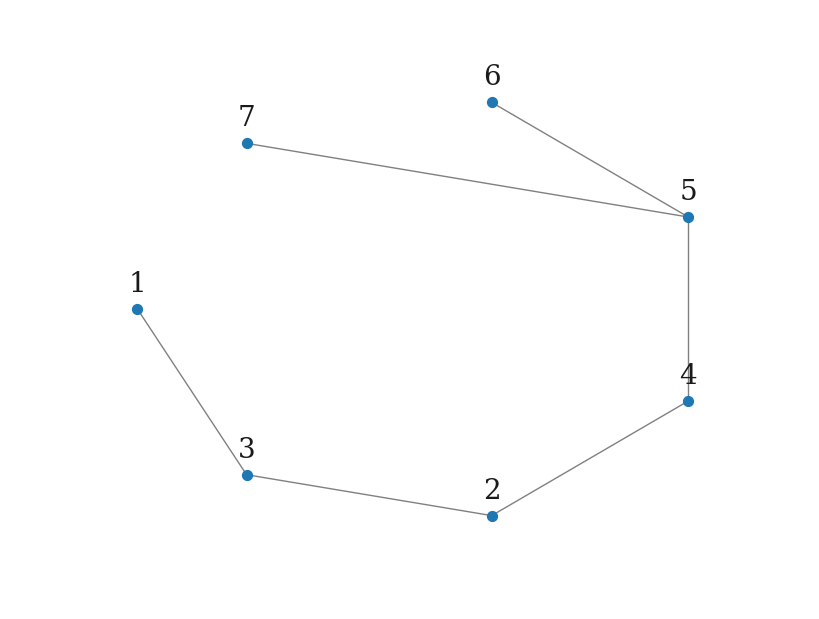

In [95]:
import networkx as nx
edges = [[1,3],[2,3],[2,4],[4,5],[5,6],[5,7]]
G = nx.from_edgelist(edges)

G.nodes[1]["community"] = 0
G.nodes[2]["community"] = 0
G.nodes[3]["community"] = 0

G.nodes[4]["community"] = 1
G.nodes[5]["community"] = 1
G.nodes[6]["community"] = 1
G.nodes[7]["community"] = 1
preds = nx.cn_soundarajan_hopcroft(G,[(1,2),(2,5),(3,4)])
print(list(preds))
draw_graph(G,pos_nodes=nx.shell_layout(G))

## Node prediction based on content features

The model is used for a node prediction task on the [Cora dataset](https://relational.fit.cvut.cz/dataset/CORA)
to predict the subject of a paper given its words and citations network.

#### Process and visualize the dataset

We load the citations data into a Pandas DataFrame edgelist.

In [96]:
def draw_graph(G, node_names={}, node_size=500, with_labels=True, node_color=None):
    pos_nodes = nx.spring_layout(G)
    nx.draw_spring(G, with_labels=with_labels, node_size=node_size, node_color=node_color, edge_color='gray', arrowsize=30)
    
    pos_attrs = {}
    for node, coords in pos_nodes.items():
        pos_attrs[node] = (coords[0], coords[1] + 0.08)
        
    #nx.draw_networkx_labels(G, pos_attrs, font_family='serif', font_size=20)
    
    plt.axis('off')
    axis = plt.gca()
    axis.set_xlim([1.2*x for x in axis.get_xlim()])
    axis.set_ylim([1.2*y for y in axis.get_ylim()])
    plt.show()

Citations shape: (5429, 2)


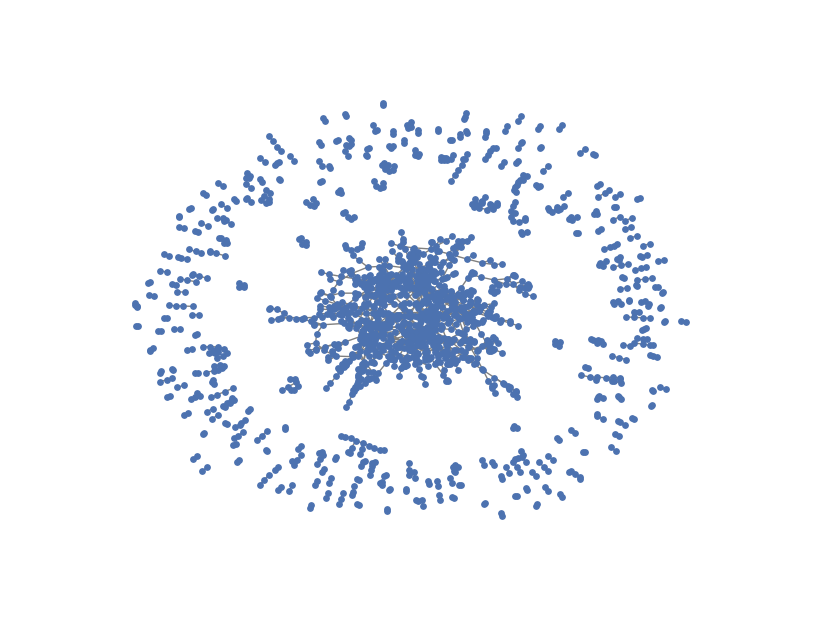

In [97]:
from tensorflow import keras

url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"

zip_file = keras.utils.get_file(
    fname="cora.tgz",
    origin=url,
    extract=True,
)
data_dir = os.path.join(os.path.dirname(zip_file), "cora")

edgelist = pd.read_csv(
    os.path.join(data_dir, "cora.cites"),
    sep="\t",
    header=None,
    names=["target", "source"],
)
print("Citations shape:", edgelist.shape)
G = nx.from_pandas_edgelist(edgelist.sample(n=1500))
draw_graph(G,node_size=15, with_labels=False)

In [128]:
dataset = datasets.Cora()
display(HTML(dataset.description))

Now we display a sample of the `citations` DataFrame.
The `target` column includes the paper ids cited by the paper ids in the `source` column.

In [98]:
edgelist.sample(frac=1).head()

,target,source
1958,13917,1120020
2952,37483,217852
4400,178718,1110546
753,3191,642827
3144,45189,976284


Now let's load the papers data into a Pandas DataFrame.

In [99]:
column_names = ["paper_id"] + [f"term_{idx}" for idx in range(1433)] + ["subject"]
papers = pd.read_csv(
    os.path.join(data_dir, "cora.content"), sep="\t", header=None, names=column_names,
)
print("Papers shape:", papers.shape)

Papers shape: (2708, 1435)


Now we display a sample of the `papers` DataFrame. The DataFrame includes the `paper_id`
and the `subject` columns, as well as 1,433 binary column representing whether a term exists
in the paper or not.

In [100]:
print(papers.sample(5).T)

             177                    2242             754            195   \
paper_id    63486                 632796            46536         232605   
term_0          0                      0                0              0   
term_1          0                      0                0              0   
term_2          0                      0                0              0   
term_3          0                      0                0              0   
...           ...                    ...              ...            ...   
term_1429       0                      0                0              0   
term_1430       0                      0                0              0   
term_1431       0                      0                0              0   
term_1432       0                      0                0              0   
subject    Theory  Probabilistic_Methods  Neural_Networks  Rule_Learning   

                         2564  
paper_id               576795  
term_0                 

Let's display the count of the papers in each subject.

In [121]:
print(papers.subject.value_counts())

subject
2    818
3    426
1    418
6    351
0    298
4    217
5    180
Name: count, dtype: int64


We convert the paper ids and the subjects into zero-based indices.

In [122]:
class_values = sorted(papers["subject"].unique())
class_idx = {name: id for id, name in enumerate(class_values)}
paper_idx = {name: idx for idx, name in enumerate(sorted(papers["paper_id"].unique()))}

papers["paper_id"] = papers["paper_id"].apply(lambda name: paper_idx[name])
edgelist["source"] = edgelist["source"].apply(lambda name: paper_idx[name])
edgelist["target"] = edgelist["target"].apply(lambda name: paper_idx[name])
papers["subject"] = papers["subject"].apply(lambda value: class_idx[value])

<Figure size 1000x1000 with 0 Axes>

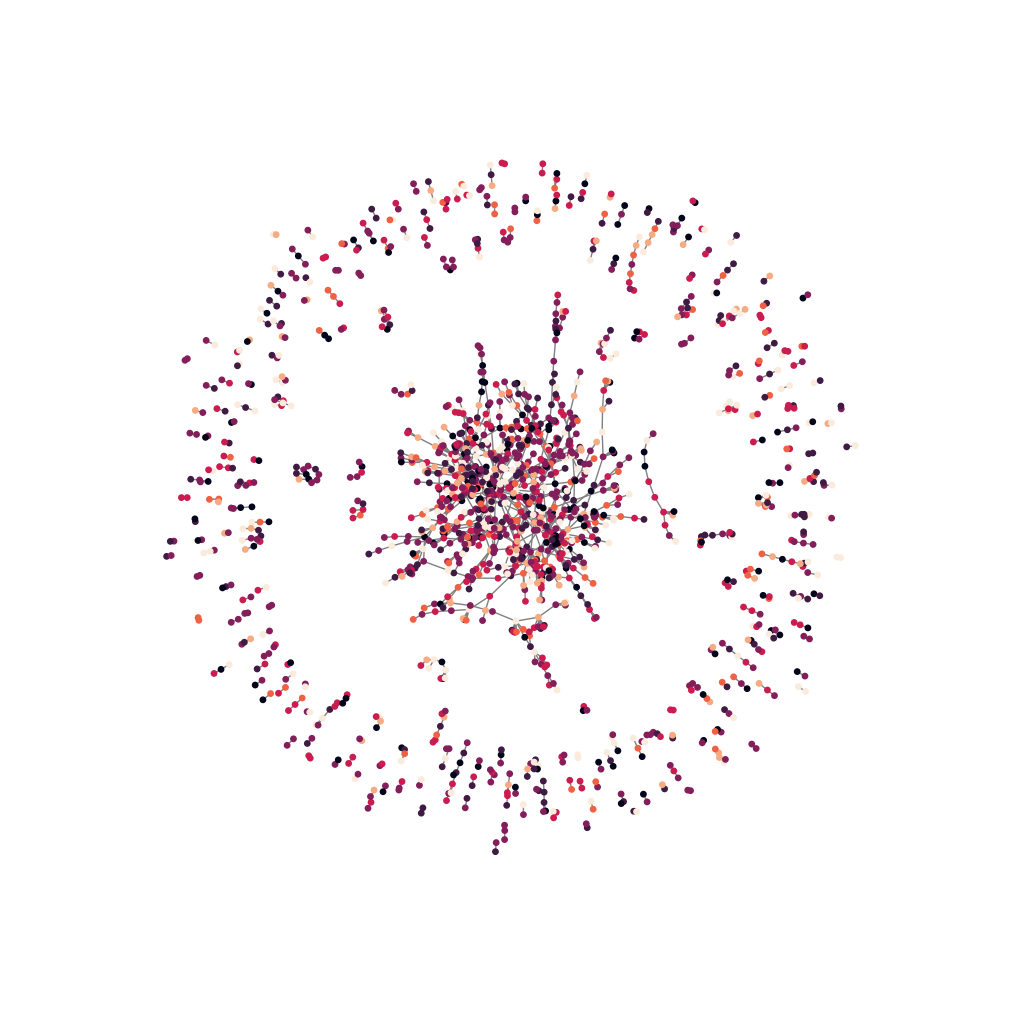

In [123]:
plt.figure(figsize=(10, 10))
colors = papers["subject"].tolist()
cora_graph = nx.from_pandas_edgelist(edgelist.sample(n=1500))
subjects = list(papers[papers["paper_id"].isin(list(cora_graph.nodes))]["subject"])
draw_graph(cora_graph, node_size=15, with_labels=False, node_color=subjects)


In [124]:
train_data, test_data = [], []

for _, group_data in papers.groupby("subject"):
    # Select around 50% of the dataset for training.
    random_selection = np.random.rand(len(group_data.index)) <= 0.5
    train_data.append(group_data[random_selection])
    test_data.append(group_data[~random_selection])

train_data = pd.concat(train_data).sample(frac=1)
test_data = pd.concat(test_data).sample(frac=1)

print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
train_data

Train data shape: (1326, 1435)
Test data shape: (1382, 1435)


,paper_id,term_0,term_1,term_2,term_3,term_4,term_5,term_6,term_7,term_8,...,term_1424,term_1425,term_1426,term_1427,term_1428,term_1429,term_1430,term_1431,term_1432,subject
1241,65,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
469,2115,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
1703,410,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
1333,817,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
235,2563,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2638,1748,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2431,156,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
957,2604,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,6
2208,1731,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [125]:
feature_names = list(set(papers.columns) - {"paper_id", "subject"})
num_features = len(feature_names)
num_classes = len(class_idx)

# Create train and test features as a numpy array.
x_train = train_data[feature_names].to_numpy()
x_test = test_data[feature_names].to_numpy()
# Create train and test targets as a numpy array.
y_train = train_data["subject"]
y_test = test_data["subject"]

In [126]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=1000)
rf.fit(x_train, y_train);

In [127]:
from sklearn import metrics

y_pred = rf.predict(x_test)

print('Precision:', metrics.precision_score(y_test, y_pred, average='weighted'))
print('Recall:', metrics.recall_score(y_test, y_pred, average='weighted'))
print('F1-Score:', metrics.f1_score(y_test, y_pred, average='weighted'))


Precision: 0.7715437136946909
Recall: 0.7554269175108539
F1-Score: 0.7521945121702209


In [71]:
#y_train.shape
#y_test.shape
#pd.concat([y_train, y_test]).shape
#list(pd.concat([y_train, y_test]))

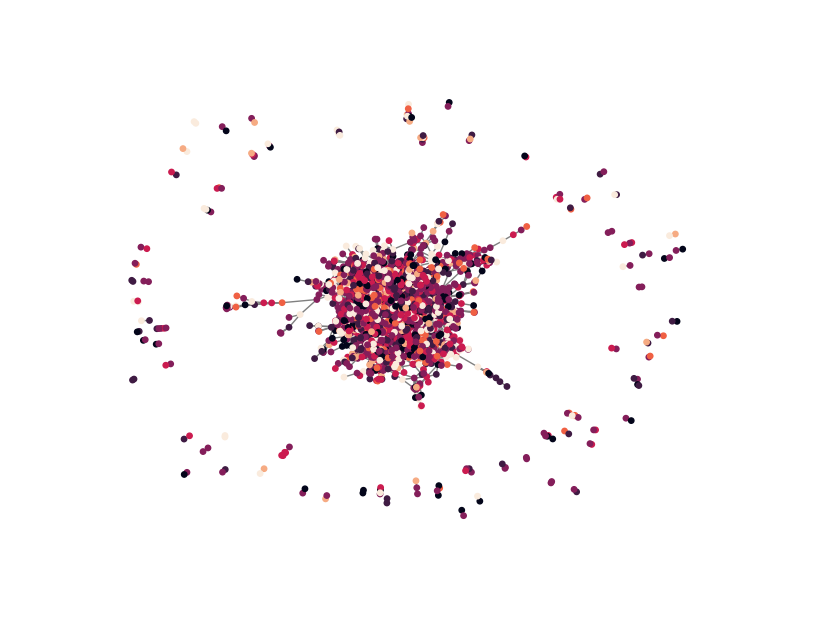

In [108]:
cora_graph = nx.from_pandas_edgelist(edgelist)
draw_graph(cora_graph, node_size=15, with_labels=False, node_color=pd.concat([y_train, y_test]))

### Playtime

<div class="alert alert-success">
PLAYTIME: Fent servir un classificador RandomForest hem predit la classe (subject) de cada article (node) basat en els termes/paraules incloses en l'article. Què ens falta? Com milloraries la predicció?
</div>

## Link prediction with Node2Vec

This section shows how to predict citation links/edges between papers using Node2Vec [[1]](#refs) on the [Cora dataset](https://relational.fit.cvut.cz/dataset/CORA) and the [stellargraph](https://github.com/stellargraph/stellargraph) library.

We're going to tackle link prediction as a supervised learning problem on top of node representations/embeddings. The embeddings are computed with the unsupervised node2vec algorithm. After obtaining embeddings, a binary classifier can be used to predict a link, or not, between any two nodes in the graph. Various hyperparameters could be relevant in obtaining the best link classifier - this demo demonstrates incorporating model selection into the pipeline for choosing the best binary operator to apply on a pair of node embeddings.

There are four steps:

1. Obtain embeddings for each node
2. For each set of hyperparameters, train a classifier
3. Select the classifier that performs the best
4. Evaluate the selected classifier on unseen data to validate its ability to generalise

<a name="refs"></a>
**References:**

[1] Node2Vec: Scalable Feature Learning for Networks. A. Grover, J. Leskovec. ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD), 2016.

### Load the dataset

The Cora dataset is loaded with the datasets method in StellarGraph.

In [109]:
dataset = datasets.Cora()
display(HTML(dataset.description))
graph, _ = dataset.load(largest_connected_component_only=True, str_node_ids=True)

In [110]:
print(graph.info())

StellarGraph: Undirected multigraph
 Nodes: 2485, Edges: 5209

 Node types:
  paper: [2485]
    Features: float32 vector, length 1433
    Edge types: paper-cites->paper

 Edge types:
    paper-cites->paper: [5209]
        Weights: all 1 (default)
        Features: none


### Construct splits of the input data

We have to carefully split the data to avoid data leakage and evaluate the algorithms correctly:

* For computing node embeddings, a **Train Graph** (`graph_train`)
* For training classifiers, a classifier **Training Set** (`examples_train`) of positive and negative edges that weren't used for computing node embeddings
* For choosing the best classifier, an **Model Selection Test Set** (`examples_model_selection`) of positive and negative edges that weren't used for computing node embeddings or training the classifier
* For the final evaluation, a **Test Graph** (`graph_test`) to compute test node embeddings with more edges than the Train Graph, and a **Test Set** (`examples_test`) of positive and negative edges not used for neither computing the test node embeddings or for classifier training or model selection

####  Test Graph

We begin with the full graph and use the `EdgeSplitter` class to produce:

* Test Graph
* Test set of positive/negative link examples

The Test Graph is the reduced graph we obtain from removing the test set of links from the full graph.

In [111]:
# Define an edge splitter on the original graph:
edge_splitter_test = EdgeSplitter(graph)

# Randomly sample a fraction p=0.1 of all positive links, and same number of negative links, from graph, and obtain the
# reduced graph graph_test with the sampled links removed:
graph_test, examples_test, labels_test = edge_splitter_test.train_test_split(
    p=0.1, method="global"
)

print(graph_test.info())

** Sampled 520 positive and 520 negative edges. **
StellarGraph: Undirected multigraph
 Nodes: 2485, Edges: 4689

 Node types:
  paper: [2485]
    Features: float32 vector, length 1433
    Edge types: paper-cites->paper

 Edge types:
    paper-cites->paper: [4689]
        Weights: all 1 (default)
        Features: none


#### Train Graph

This time, we use the `EdgeSplitter` on the Test Graph, and perform a train/test split on the examples to produce:

* Train Graph
* Training set of link examples
* Set of link examples for model selection


In [112]:
# Do the same process to compute a training subset from within the test graph
edge_splitter_train = EdgeSplitter(graph_test, graph)
graph_train, examples, labels = edge_splitter_train.train_test_split(
    p=0.1, method="global"
)
(
    examples_train,
    examples_model_selection,
    labels_train,
    labels_model_selection,
) = train_test_split(examples, labels, train_size=0.75, test_size=0.25)

print(graph_train.info())

** Sampled 468 positive and 468 negative edges. **
StellarGraph: Undirected multigraph
 Nodes: 2485, Edges: 4221

 Node types:
  paper: [2485]
    Features: float32 vector, length 1433
    Edge types: paper-cites->paper

 Edge types:
    paper-cites->paper: [4221]
        Weights: all 1 (default)
        Features: none


Below is a summary of the different splits that have been created in this section

In [113]:
pd.DataFrame(
    [
        (
            "Training Set",
            len(examples_train),
            "Train Graph",
            "Test Graph",
            "Train the Link Classifier",
        ),
        (
            "Model Selection",
            len(examples_model_selection),
            "Train Graph",
            "Test Graph",
            "Select the best Link Classifier model",
        ),
        (
            "Test set",
            len(examples_test),
            "Test Graph",
            "Full Graph",
            "Evaluate the best Link Classifier",
        ),
    ],
    columns=("Split", "Number of Examples", "Hidden from", "Picked from", "Use"),
).set_index("Split")

,Number of Examples,Hidden from,Picked from,Use
Split,,,,
Training Set,702,Train Graph,Test Graph,Train the Link Classifier
Model Selection,234,Train Graph,Test Graph,Select the best Link Classifier model
Test set,1040,Test Graph,Full Graph,Evaluate the best Link Classifier


### Node2Vec

We use Node2Vec [[1]](#refs), to calculate node embeddings. These embeddings are learned in such a way to ensure that nodes that are close in the graph remain close in the embedding space. Node2Vec first involves running random walks on the graph to obtain our context pairs, and using these to train a Word2Vec model.

These are the set of parameters we can use:

* `p` - Random walk parameter "p"
* `q` - Random walk parameter "q"
* `dimensions` - Dimensionality of node2vec embeddings
* `num_walks` - Number of walks from each node
* `walk_length` - Length of each random walk
* `window_size` - Context window size for Word2Vec
* `num_iter` - number of SGD iterations (epochs)
* `workers` - Number of workers for Word2Vec

In [114]:
p = 1.0
q = 1.0
dimensions = 128
num_walks = 10
walk_length = 80
window_size = 10
num_iter = 1
workers = multiprocessing.cpu_count()

In [115]:
from stellargraph.data import BiasedRandomWalk
from gensim.models import Word2Vec


def node2vec_embedding(graph, name):
    rw = BiasedRandomWalk(graph)
    walks = rw.run(graph.nodes(), n=num_walks, length=walk_length, p=p, q=q)
    print(f"Number of random walks for '{name}': {len(walks)}")
    
    model = Word2Vec(
        walks,
        window=window_size,
        min_count=0,
        sg=1,
        workers=workers,
    )
#size=dimensions,
# iter=num_iter,
    def get_embedding(u):
        return model.wv[u]

    return get_embedding

In [116]:
embedding_train = node2vec_embedding(graph_train, "Train Graph")

Number of random walks for 'Train Graph': 24850


### Train and evaluate the link prediction model

There are a few steps involved in using the Word2Vec model to perform link prediction:
1. We calculate link/edge embeddings for the positive and negative edge samples by applying a binary operator on the embeddings of the source and target nodes of each sampled edge.
2. Given the embeddings of the positive and negative examples, we train a logistic regression classifier to predict a binary value indicating whether an edge between two nodes should exist or not.
3. We evaluate the performance of the link classifier for each of the 4 operators on the training data with node embeddings calculated on the **Train Graph** (`graph_train`), and select the best classifier.
4. The best classifier is then used to calculate scores on the test data with node embeddings calculated on the **Test Graph** (`graph_test`).

Below are a set of helper functions that let us repeat these steps for each of the binary operators.

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler


# 1. link embeddings
def link_examples_to_features(link_examples, transform_node, binary_operator):
    return [
        binary_operator(transform_node(src), transform_node(dst))
        for src, dst in link_examples
    ]


# 2. training classifier
def train_link_prediction_model(
    link_examples, link_labels, get_embedding, binary_operator
):
    clf = link_prediction_classifier()
    link_features = link_examples_to_features(
        link_examples, get_embedding, binary_operator
    )
    clf.fit(link_features, link_labels)
    return clf


def link_prediction_classifier(max_iter=2000):
    lr_clf = LogisticRegressionCV(Cs=10, cv=10, scoring="roc_auc", max_iter=max_iter)
    return Pipeline(steps=[("sc", StandardScaler()), ("clf", lr_clf)])


# 3. and 4. evaluate classifier
def evaluate_link_prediction_model(
    clf, link_examples_test, link_labels_test, get_embedding, binary_operator
):
    link_features_test = link_examples_to_features(
        link_examples_test, get_embedding, binary_operator
    )
    score = evaluate_roc_auc(clf, link_features_test, link_labels_test)
    return score


def evaluate_roc_auc(clf, link_features, link_labels):
    predicted = clf.predict_proba(link_features)

    # check which class corresponds to positive links
    positive_column = list(clf.classes_).index(1)
    return roc_auc_score(link_labels, predicted[:, positive_column])

We consider 4 different operators:

* *Hadamard*
* $L_1$
* $L_2$
* *average*

The paper [[1]](#refs) provides a detailed description of these operators. All operators produce link embeddings that have equal dimensionality to the input node embeddings (128 dimensions for our example).

In [118]:
def operator_hadamard(u, v):
    return u * v


def operator_l1(u, v):
    return np.abs(u - v)


def operator_l2(u, v):
    return (u - v) ** 2


def operator_avg(u, v):
    return (u + v) / 2.0


def run_link_prediction(binary_operator):
    clf = train_link_prediction_model(
        examples_train, labels_train, embedding_train, binary_operator
    )
    score = evaluate_link_prediction_model(
        clf,
        examples_model_selection,
        labels_model_selection,
        embedding_train,
        binary_operator,
    )

    return {
        "classifier": clf,
        "binary_operator": binary_operator,
        "score": score,
    }


binary_operators = [operator_hadamard, operator_l1, operator_l2, operator_avg]

In [83]:
results = [run_link_prediction(op) for op in binary_operators]
best_result = max(results, key=lambda result: result["score"])

print(f"Best result from '{best_result['binary_operator'].__name__}'")

pd.DataFrame(
    [(result["binary_operator"].__name__, result["score"]) for result in results],
    columns=("name", "ROC AUC score"),
).set_index("name")

Best result from 'operator_l2'


,ROC AUC score
name,
operator_hadamard,0.851
operator_l1,0.867
operator_l2,0.876
operator_avg,0.533


### Evaluate the best model using the test set

Now that we've trained and selected our best model, we use a test set of embeddings and calculate a final evaluation score.

In [119]:
embedding_test = node2vec_embedding(graph_test, "Test Graph")

Number of random walks for 'Test Graph': 24850


In [85]:
test_score = evaluate_link_prediction_model(
    best_result["classifier"],
    examples_test,
    labels_test,
    embedding_test,
    best_result["binary_operator"],
)
print(
    f"ROC AUC score on test set using '{best_result['binary_operator'].__name__}': {test_score}"
)

ROC AUC score on test set using 'operator_l2': 0.9022448224852071


### Playtime

<div class="alert alert-success">
PLAYTIME: Repeat the node prediction task, seen in the previous section. For doing so, modify the Node2Vec embedding method to create a embedding that include both the paper content and the network topology (citations) for the whole cora dataset. Idea: Combine the previous computed embeddings and the features based on the paper content.


Including the network relationship improve the performance in the node classification?
How the dimension of the embedding affects the node prediction performance?
</div>